This code generates the combined csv that are produced by the pruning and benchmarking scripts. A few tinkers need to be made to the CSVs, like removing the unnecessary rows and merging the values for energy and performancy on to the same row, but once the individual rows are representative of a single model, this code will combine them.

In [ ]:
import pandas as pd
import os

# Define the base directory where your CNN folder is located
base_dir = '/Users/arihangupta/Downloads/pruning_project_data/CNN'

# Define the datasets to process
datasets = ['bloodmnist', 'dermamnist', 'pathmnist']

for dataset in datasets:
    print(f"\nProcessing {dataset}...")
    
    # Define file paths with absolute paths
    metrics_file = os.path.join(base_dir, f'CNN_pruned_models/{dataset}/{dataset}_combined_pruning_kd_metrics_with_energy.csv')
    timing_file = os.path.join(base_dir, f'timing_exps/{dataset}_results.csv')
    output_file = os.path.join(base_dir, f'{dataset}_combined_results.csv')
    
    # Check if files exist
    if not os.path.exists(metrics_file):
        print(f"  Warning: {metrics_file} not found, skipping...")
        continue
    if not os.path.exists(timing_file):
        print(f"  Warning: {timing_file} not found, skipping...")
        continue
    
    # Read the CSV files
    df_metrics = pd.read_csv(metrics_file)
    df_timing = pd.read_csv(timing_file)
    
    # Remove any unnamed columns from both dataframes
    df_metrics = df_metrics.loc[:, ~df_metrics.columns.str.contains('^Unnamed')]
    df_timing = df_timing.loc[:, ~df_timing.columns.str.contains('^Unnamed')]
    
    print(f"  Metrics file shape: {df_metrics.shape}")
    print(f"  Timing file shape: {df_timing.shape}")
    
    # Perform inner join on Variant (from metrics) and pruning_method (from timing)
    df_combined = pd.merge(
        df_metrics, 
        df_timing, 
        left_on='Variant', 
        right_on='pruning_method', 
        how='inner'
    )
    
    print(f"  Combined file shape: {df_combined.shape}")
    print(f"  Matched {len(df_combined)} rows")
    
    # Save the combined file
    df_combined.to_csv(output_file, index=False)
    print(f"  Saved to: {output_file}")

print("\nAll datasets processed!")

This code works to average all of the results (now in one file per dataset) and also store the the SD. This merged result is then used for visualization.

In [ ]:
import pandas as pd
import os
import numpy as np

# Define the base directory
base_dir = '/Users/arihangupta/Downloads/pruning_project_data/CNN'
output_dir = os.path.join(base_dir, 'merged_results')

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Define the datasets to process
datasets = ['bloodmnist', 'dermamnist', 'pathmnist']

# Define columns that should be averaged (numerical columns that make sense to average)
columns_to_average = [
    'Acc', 'AUC', 'Loss',
    'InferenceTime_per_batch_s', 'PeakRAM_MB',
    'RetrainEnergy_kWh', 'RetrainEmissions_kg',
    'images_processed', 'elapsed_s', 'throughput_imgs_per_s',
    'auc', 'median_batch_ms', 'p50_ms', 'p90_ms',
    'peak_gpu_mem_MB', 'avg_power_W',
    'energy_kWh_total', 'energy_kWh_per_batch', 'energy_kWh_per_image',
    'emissions_kg_total', 'cpu_power_w', 'gpu_power_w', 'ram_power_w'
]

# Define grouping columns
grouping_columns = [
    'model_name', 'pruning_method', 'sparsity', 
    'stored_precision', 'batch_size', 'runtime_precision'
]

for dataset in datasets:
    print(f"\nProcessing {dataset}...")
    
    # Read the combined results file
    input_file = os.path.join(base_dir, f'{dataset}_combined_results.csv')
    
    if not os.path.exists(input_file):
        print(f"  Warning: {input_file} not found, skipping...")
        continue
    
    df = pd.read_csv(input_file)
    print(f"  Original shape: {df.shape}")
    
    # Filter out rows where stored_precision != runtime_precision
    df_filtered = df[df['stored_precision'] == df['runtime_precision']].copy()
    print(f"  After filtering mismatched precisions: {df_filtered.shape}")
    
    # Group by the specified columns and aggregate
    agg_dict = {}
    
    # For columns to average, use both mean and std
    for col in columns_to_average:
        if col in df_filtered.columns:
            agg_dict[col] = ['mean', 'std']
    
    # For other columns, take the first value (they should be the same within groups)
    for col in df_filtered.columns:
        if col not in grouping_columns and col not in columns_to_average and col not in ['run_id', 'rep']:
            agg_dict[col] = 'first'
    
    # Perform the aggregation
    df_averaged = df_filtered.groupby(grouping_columns, as_index=False).agg(agg_dict)
    
    # Flatten the multi-level column names
    new_columns = []
    for col in df_averaged.columns:
        if isinstance(col, tuple):
            if col[1] == 'mean':
                new_columns.append(col[0])
            elif col[1] == 'std':
                new_columns.append(f"{col[0]}_sd")
            else:
                new_columns.append(col[0])
        else:
            new_columns.append(col)
    
    df_averaged.columns = new_columns
    
    # Reorder columns so that each averaged column is followed by its _sd column
    final_columns = []
    processed_cols = set()
    
    for col in df_averaged.columns:
        if col not in processed_cols:
            final_columns.append(col)
            processed_cols.add(col)
            # Check if there's a corresponding _sd column
            sd_col = f"{col}_sd"
            if sd_col in df_averaged.columns and sd_col not in processed_cols:
                final_columns.append(sd_col)
                processed_cols.add(sd_col)
    
    df_averaged = df_averaged[final_columns]
    
    print(f"  After averaging runs: {df_averaged.shape}")
    print(f"  Averaged {len(df_filtered) - len(df_averaged)} rows into {len(df_averaged)} groups")
    
    # Save the result
    output_file = os.path.join(output_dir, f'{dataset}_averaged_results.csv')
    df_averaged.to_csv(output_file, index=False)
    print(f"  Saved to: {output_file}")

print("\nAll datasets processed!")
print(f"Results saved to: {output_dir}")


################################################################################
# Processing BLOODMNIST
################################################################################
Normalization formulas saved to: /Users/arihangupta/Downloads/pruning_project_data/CNN/Visuals/bloodmnist_normalization_formulas.txt
Loaded CSV with 16 rows

Processing Batch Size 8
LaTeX data file saved to: /Users/arihangupta/Downloads/pruning_project_data/CNN/Visuals/bloodmnist_batch8_data.tex
Radar plot (BIG FONTS) saved to: /Users/arihangupta/Downloads/pruning_project_data/CNN/Visuals/cnn_radar_bloodmnist_batch8_BIGFONT.png


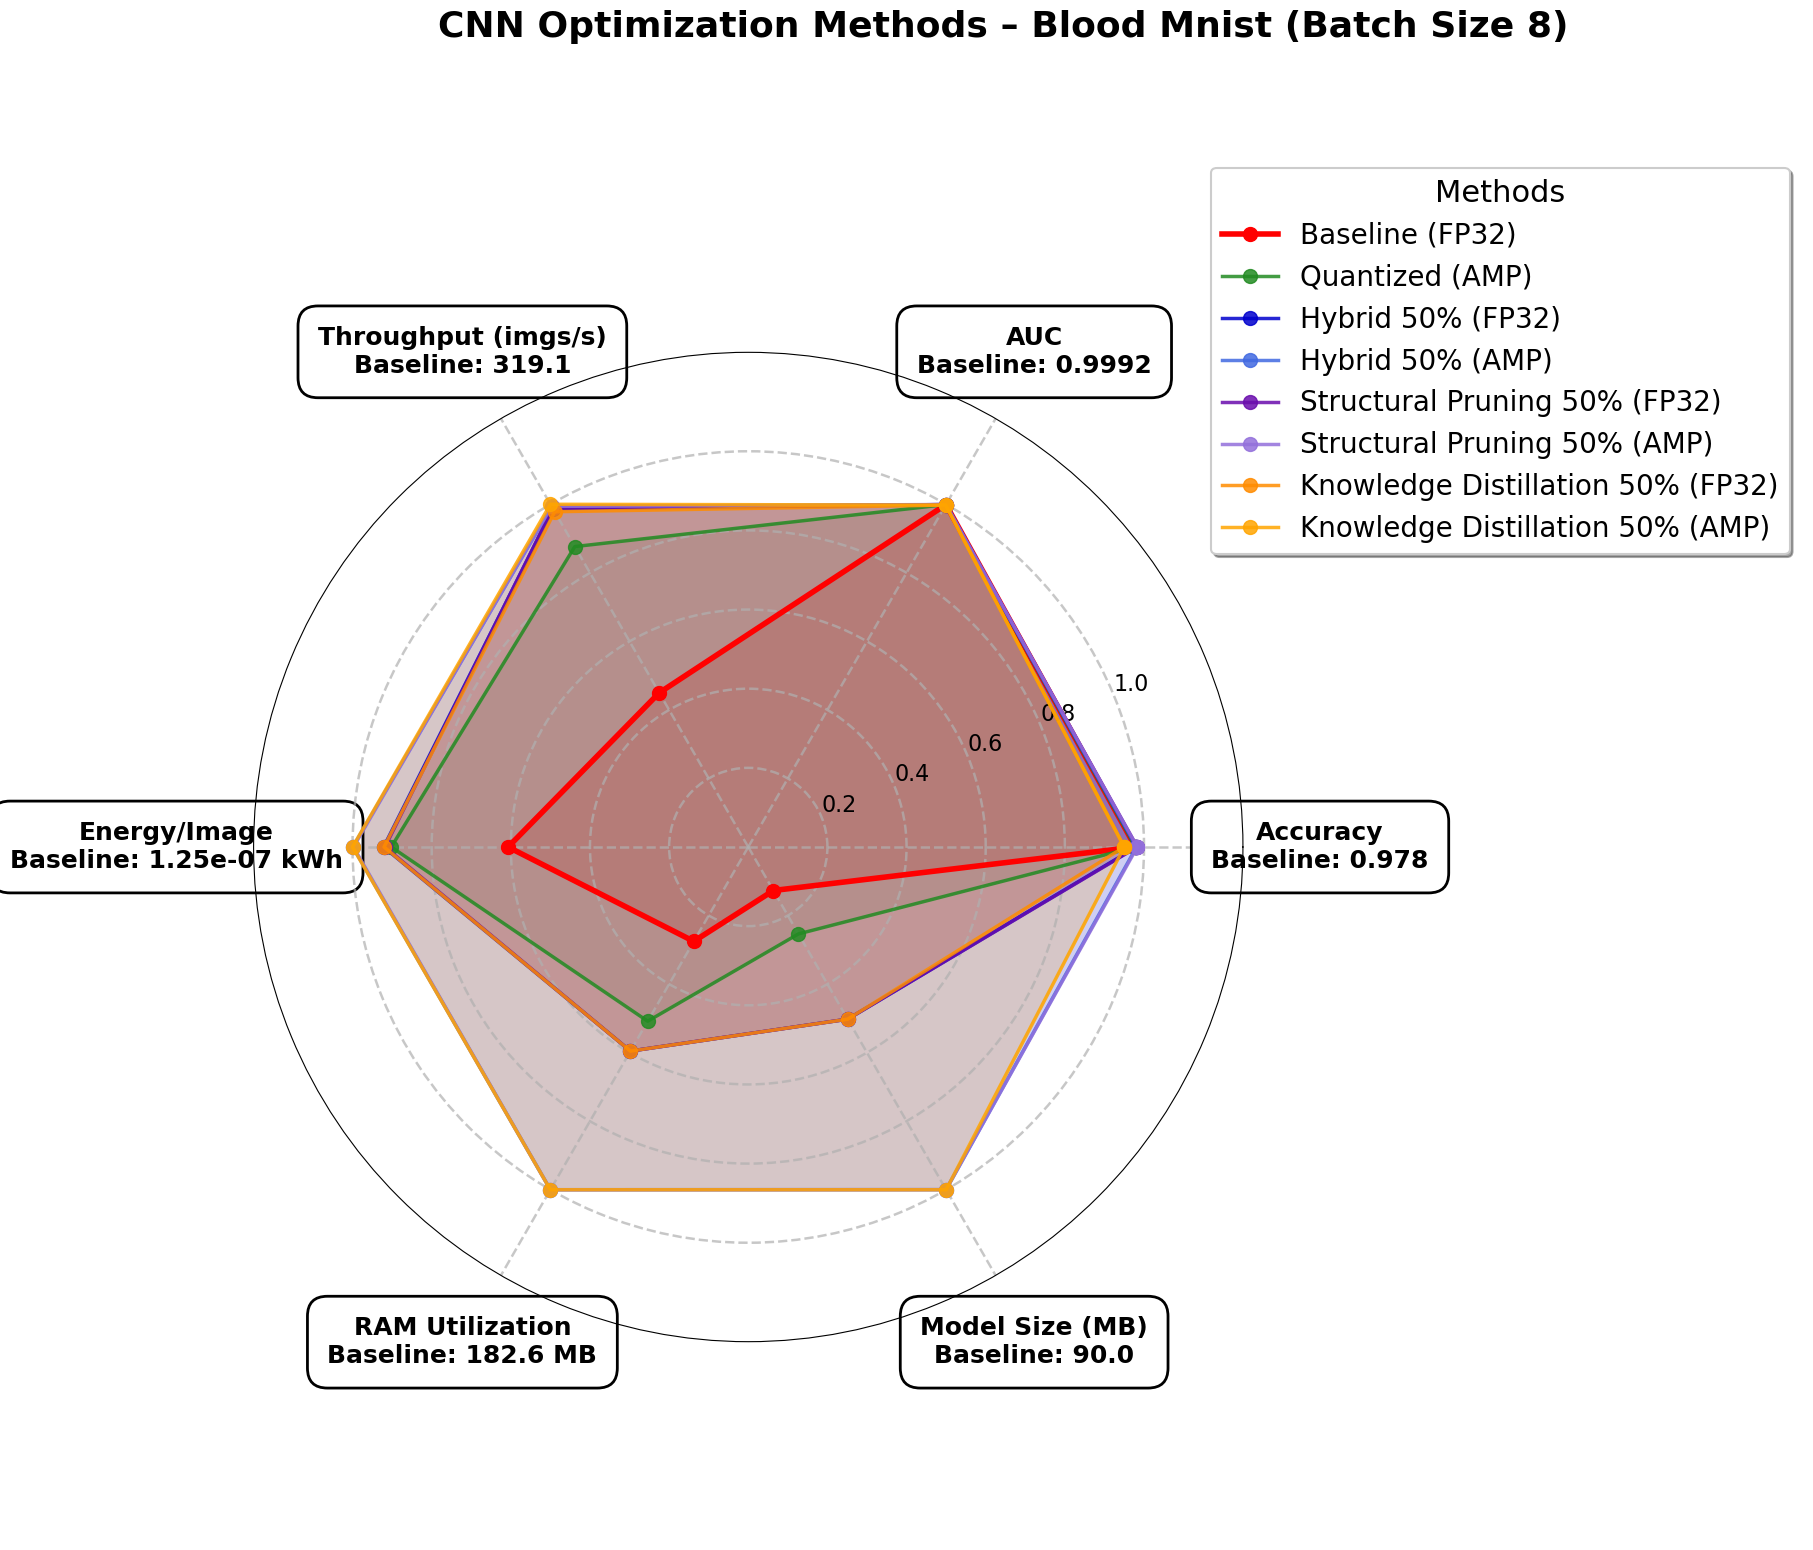


Performance Summary (Batch Size 8)
Model                                         Accuracy     AUC          Throughput      Energy/img      GPU RAM (MB)    Size (MB)   
--------------------------------------------------------------------------------------------------------------------------------------------
Baseline (FP32)                               0.9784       0.999175     319.14          1.25e-07        182.6           90.0        
Quantized (AMP)                               0.9784       0.999194     621.75          8.38e-08        98.9            45.1        
Hybrid 50% (FP32)                             0.9810       0.999155     700.23          8.20e-08        84.4            22.8        
Hybrid 50% (AMP)                              0.9810       0.998927     704.66          7.56e-08        50.3            11.4        
Structural Pruning 50% (FP32)                 0.9830       0.999229     701.08          8.23e-08        84.4            22.8        
Structural Pruning 50% (A

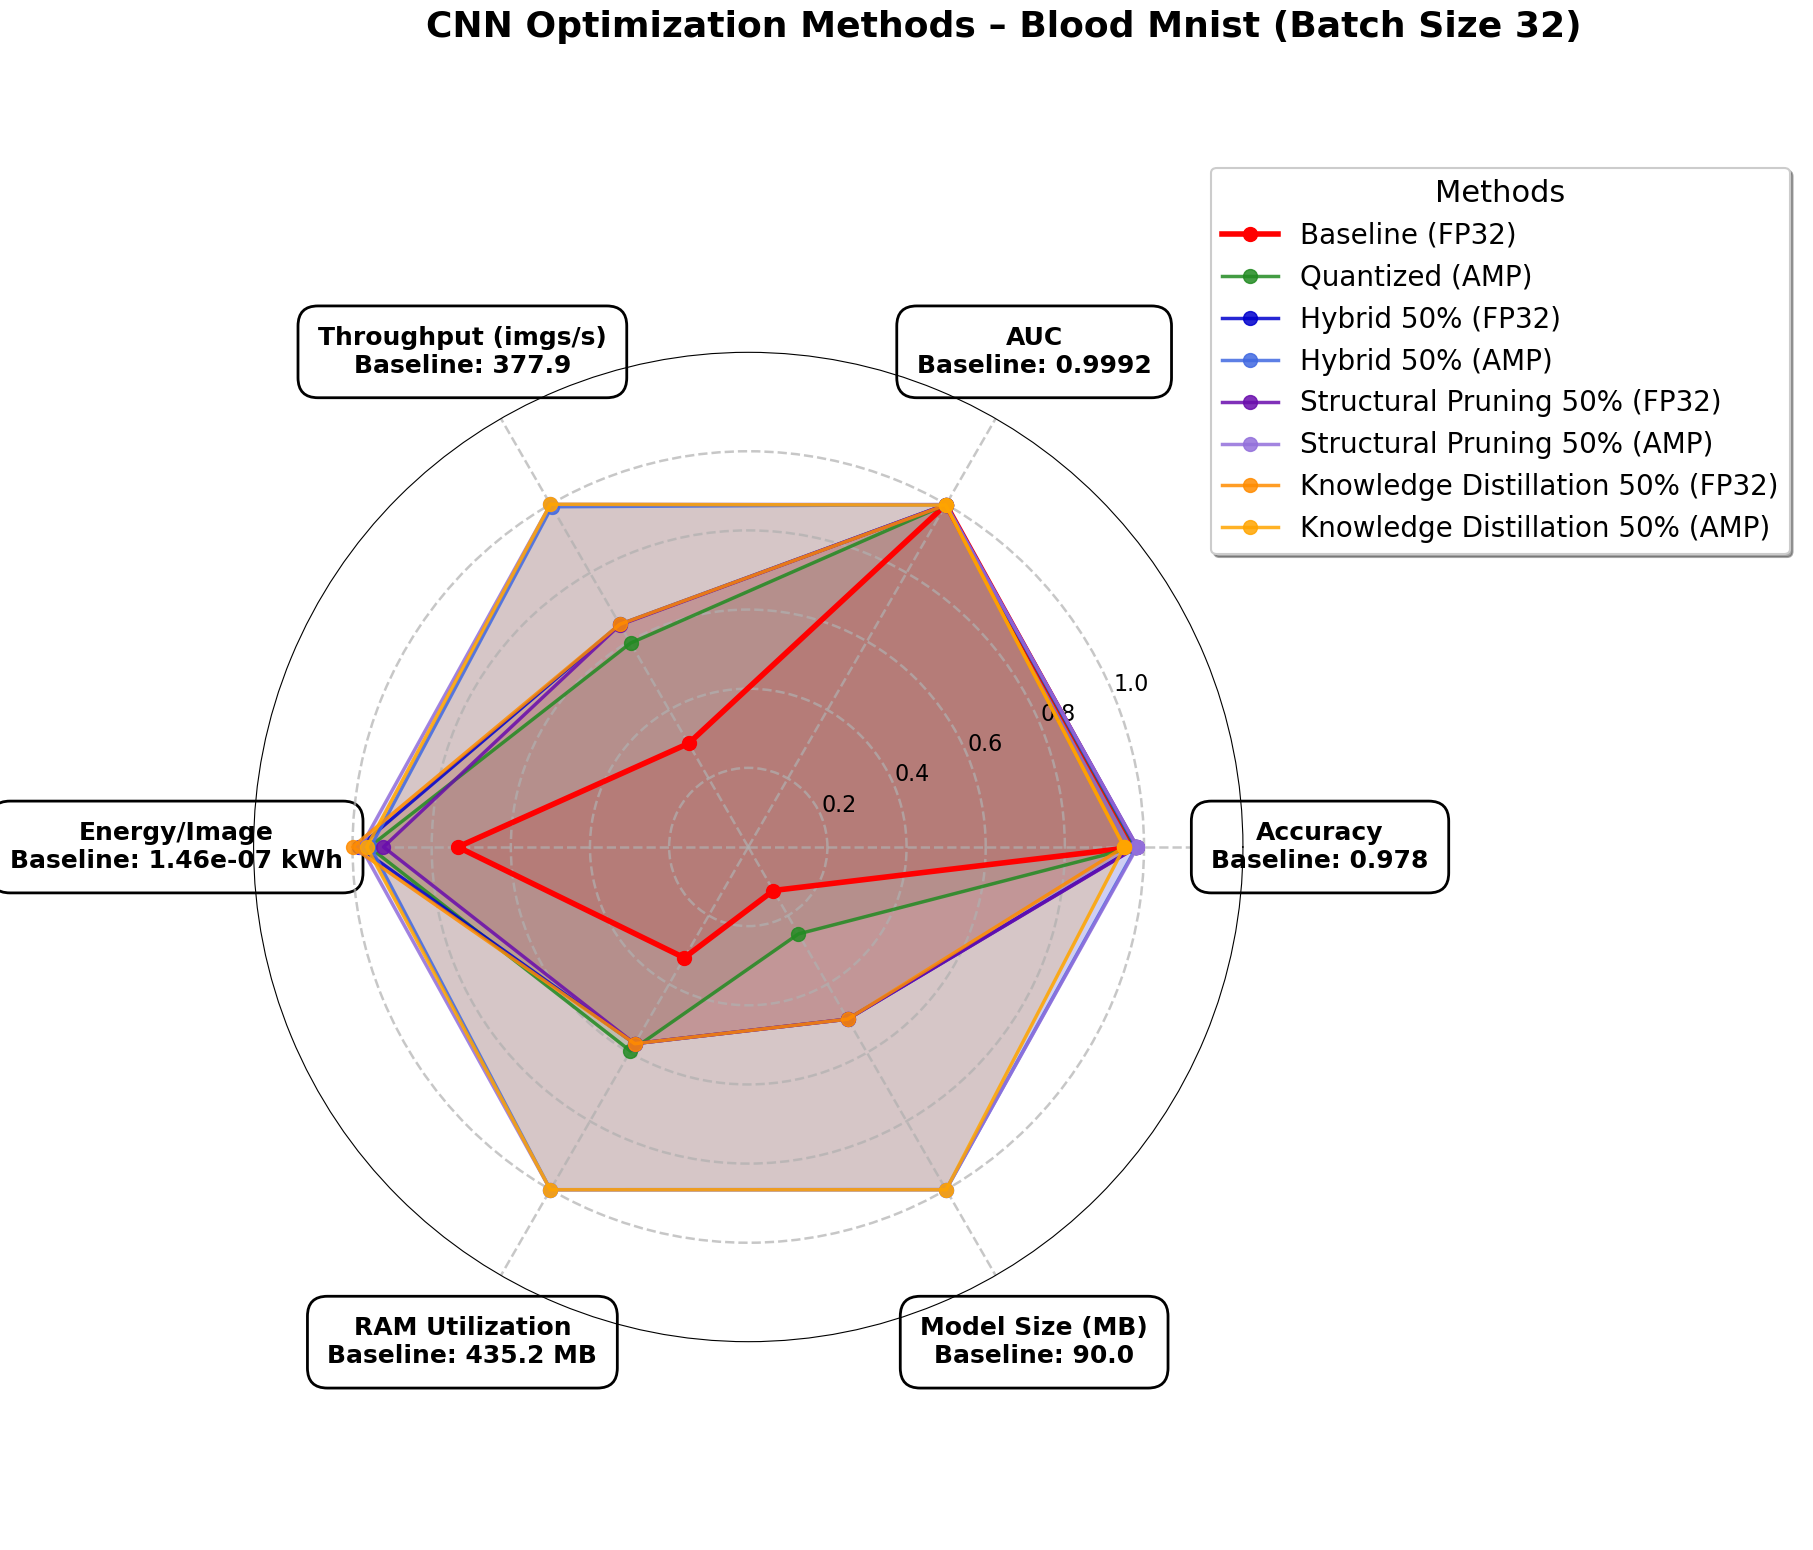


Performance Summary (Batch Size 32)
Model                                         Accuracy     AUC          Throughput      Energy/img      GPU RAM (MB)    Size (MB)   
--------------------------------------------------------------------------------------------------------------------------------------------
Baseline (FP32)                               0.9784       0.999175     377.88          1.46e-07        435.2           90.0        
Quantized (AMP)                               0.9784       0.999194     744.41          1.12e-07        236.4           45.1        
Hybrid 50% (FP32)                             0.9810       0.999155     812.66          1.09e-07        245.2           22.8        
Hybrid 50% (AMP)                              0.9810       0.998927     1242.11         1.12e-07        140.7           11.4        
Structural Pruning 50% (FP32)                 0.9830       0.999229     811.03          1.16e-07        245.2           22.8        
Structural Pruning 50% (

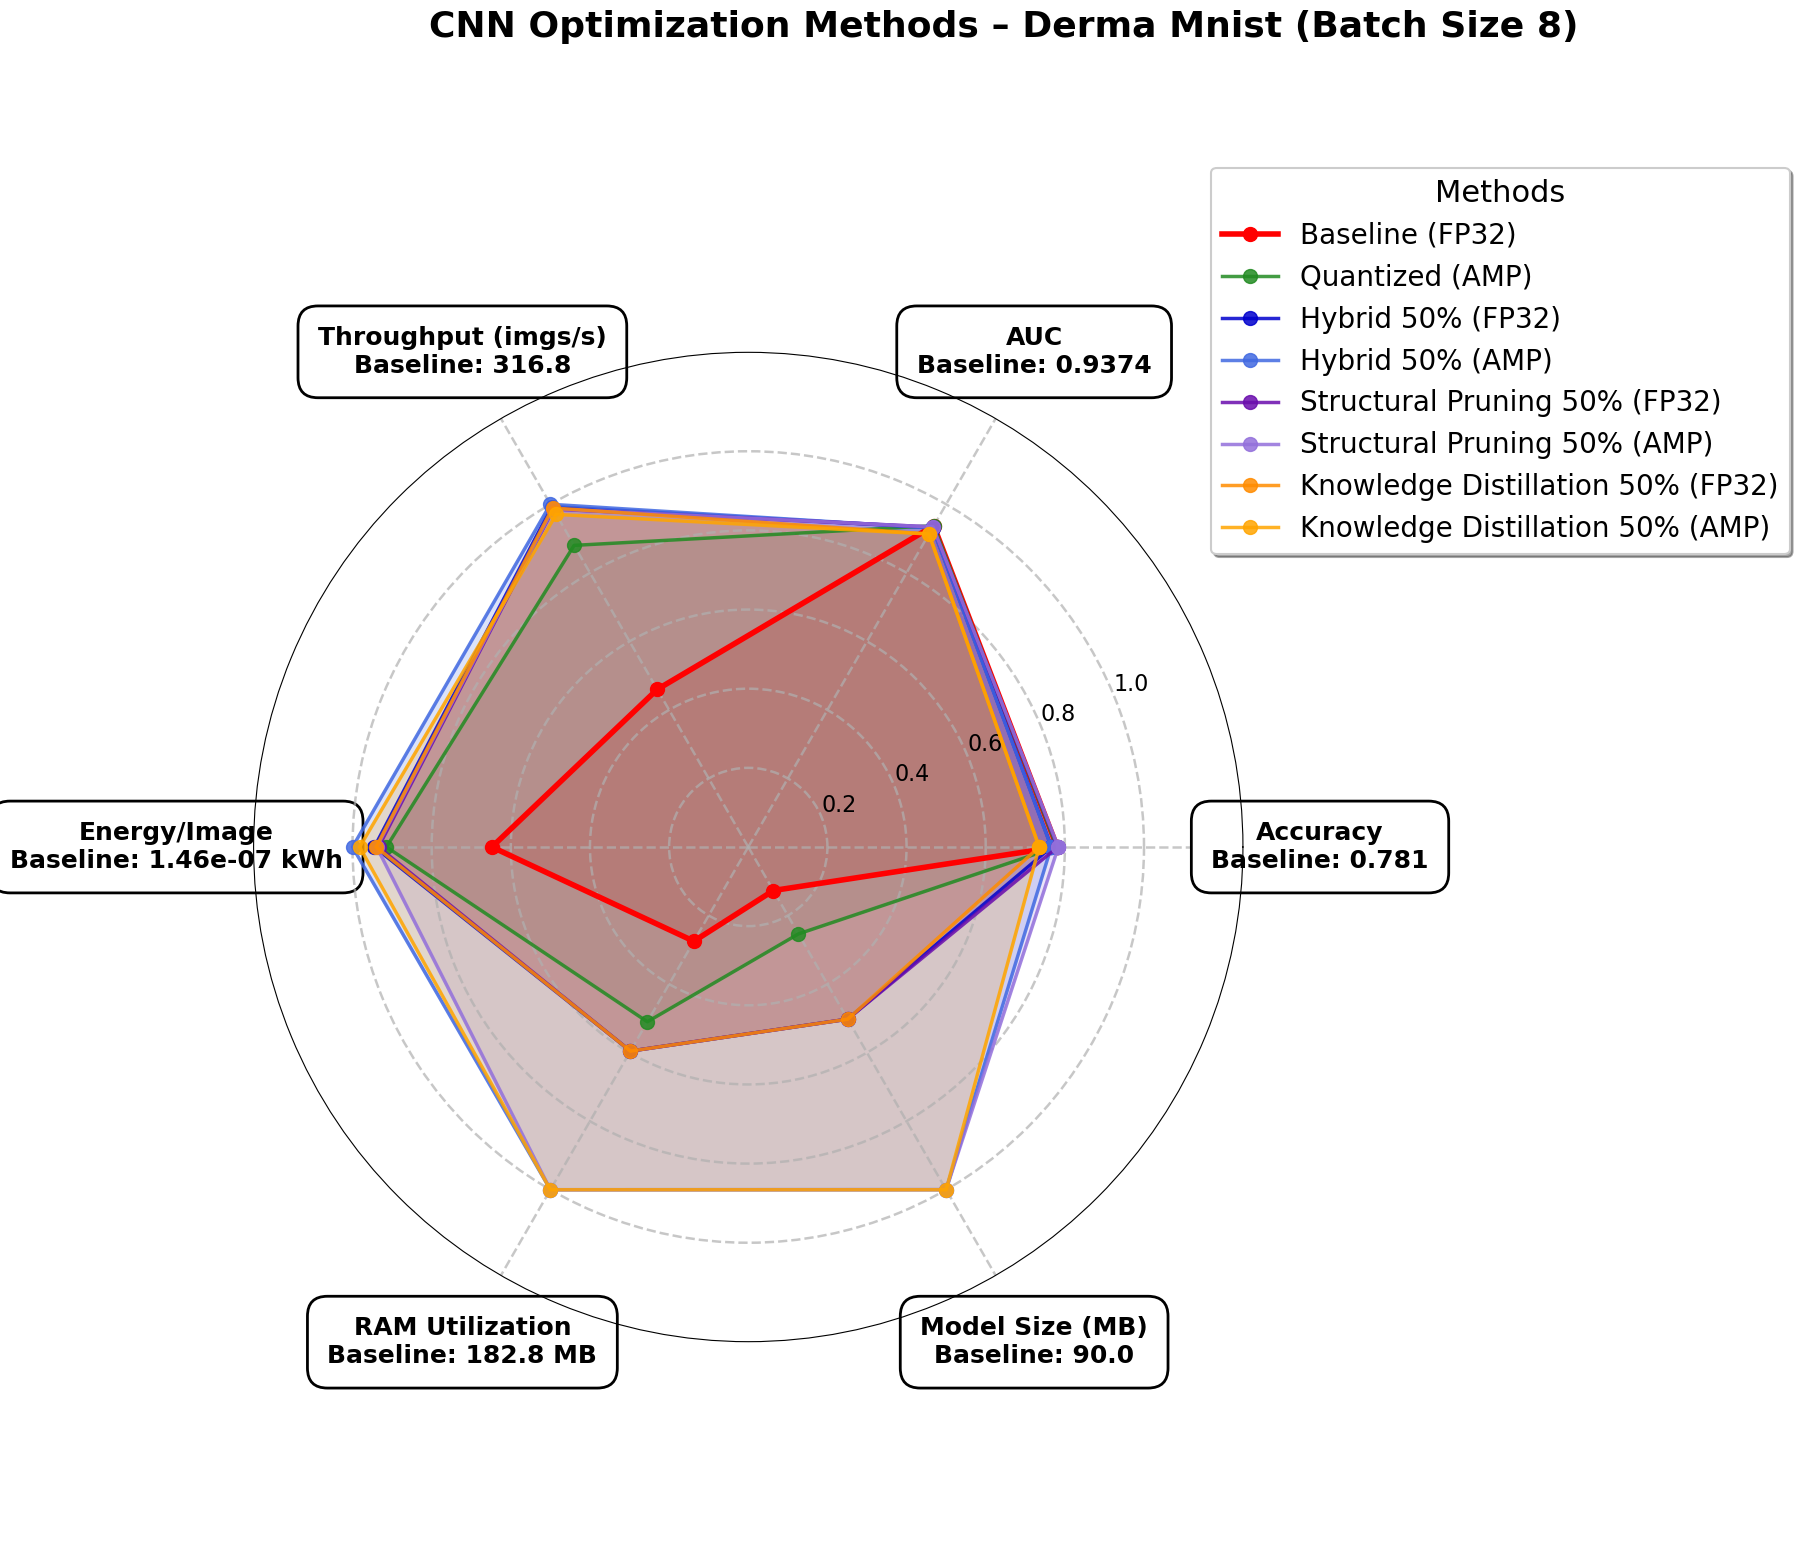


Performance Summary (Batch Size 8)
Model                                         Accuracy     AUC          Throughput      Energy/img      GPU RAM (MB)    Size (MB)   
--------------------------------------------------------------------------------------------------------------------------------------------
Baseline (FP32)                               0.7805       0.937400     316.83          1.46e-07        182.8           90.0        
Quantized (AMP)                               0.7796       0.937391     606.34          1.03e-07        98.6            45.1        
Hybrid 50% (FP32)                             0.7661       0.931823     684.18          1.00e-07        84.4            22.8        
Hybrid 50% (AMP)                              0.7656       0.930908     688.96          9.46e-08        50.3            11.4        
Structural Pruning 50% (FP32)                 0.7820       0.933874     679.22          1.01e-07        84.4            22.8        
Structural Pruning 50% (A

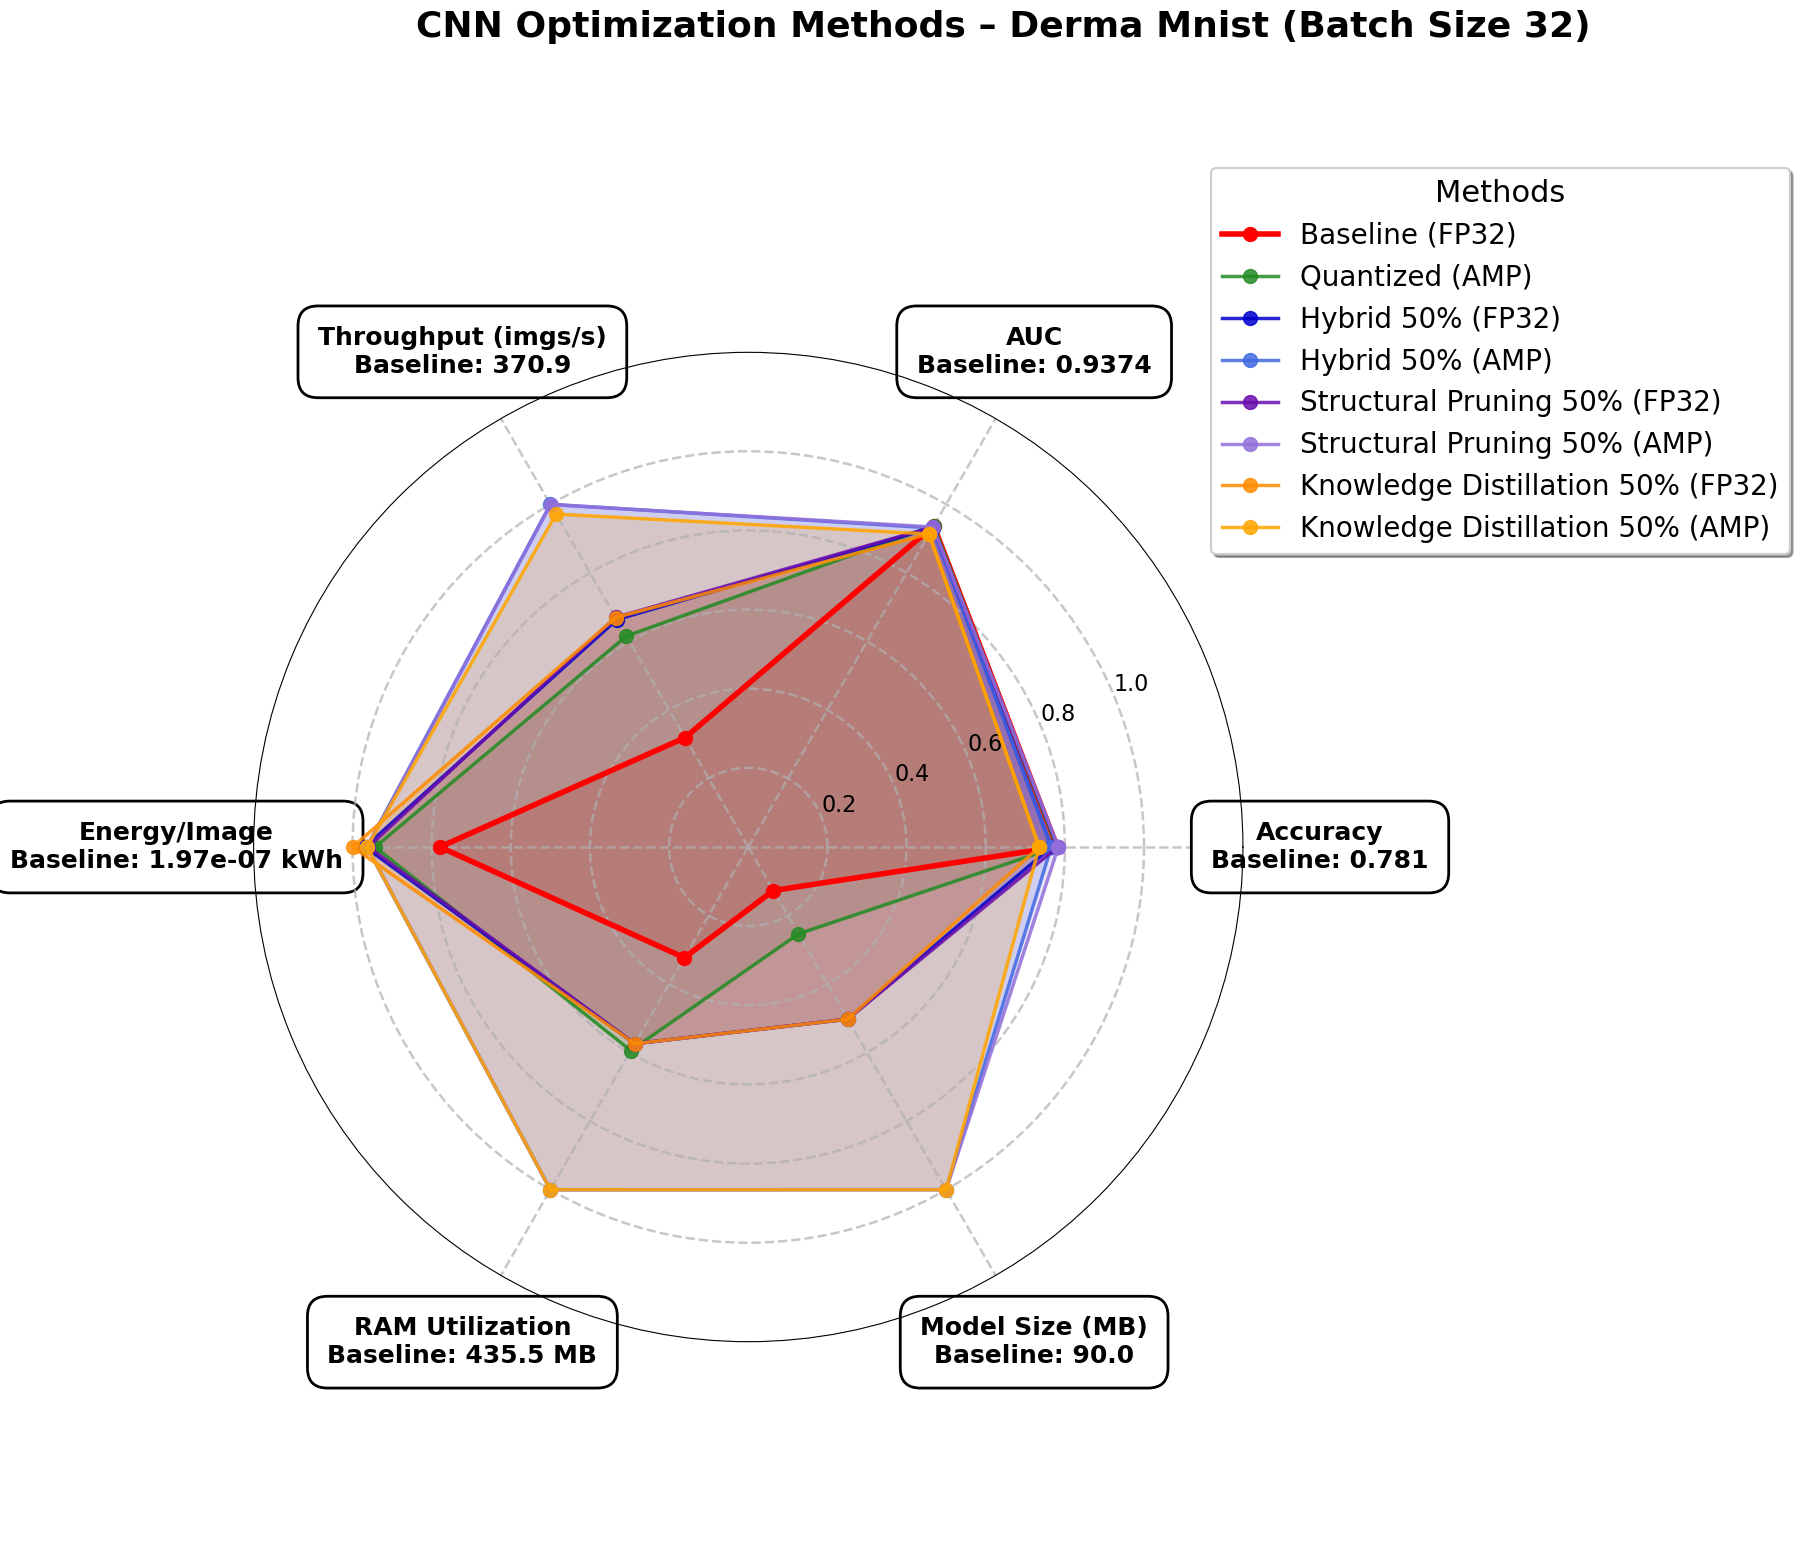


Performance Summary (Batch Size 32)
Model                                         Accuracy     AUC          Throughput      Energy/img      GPU RAM (MB)    Size (MB)   
--------------------------------------------------------------------------------------------------------------------------------------------
Baseline (FP32)                               0.7805       0.937400     370.94          1.97e-07        435.5           90.0        
Quantized (AMP)                               0.7796       0.937391     715.50          1.63e-07        236.9           45.1        
Hybrid 50% (FP32)                             0.7661       0.931823     771.46          1.58e-07        245.2           22.8        
Hybrid 50% (AMP)                              0.7656       0.930908     1162.21         1.59e-07        140.7           11.4        
Structural Pruning 50% (FP32)                 0.7820       0.933874     778.76          1.60e-07        245.2           22.8        
Structural Pruning 50% (

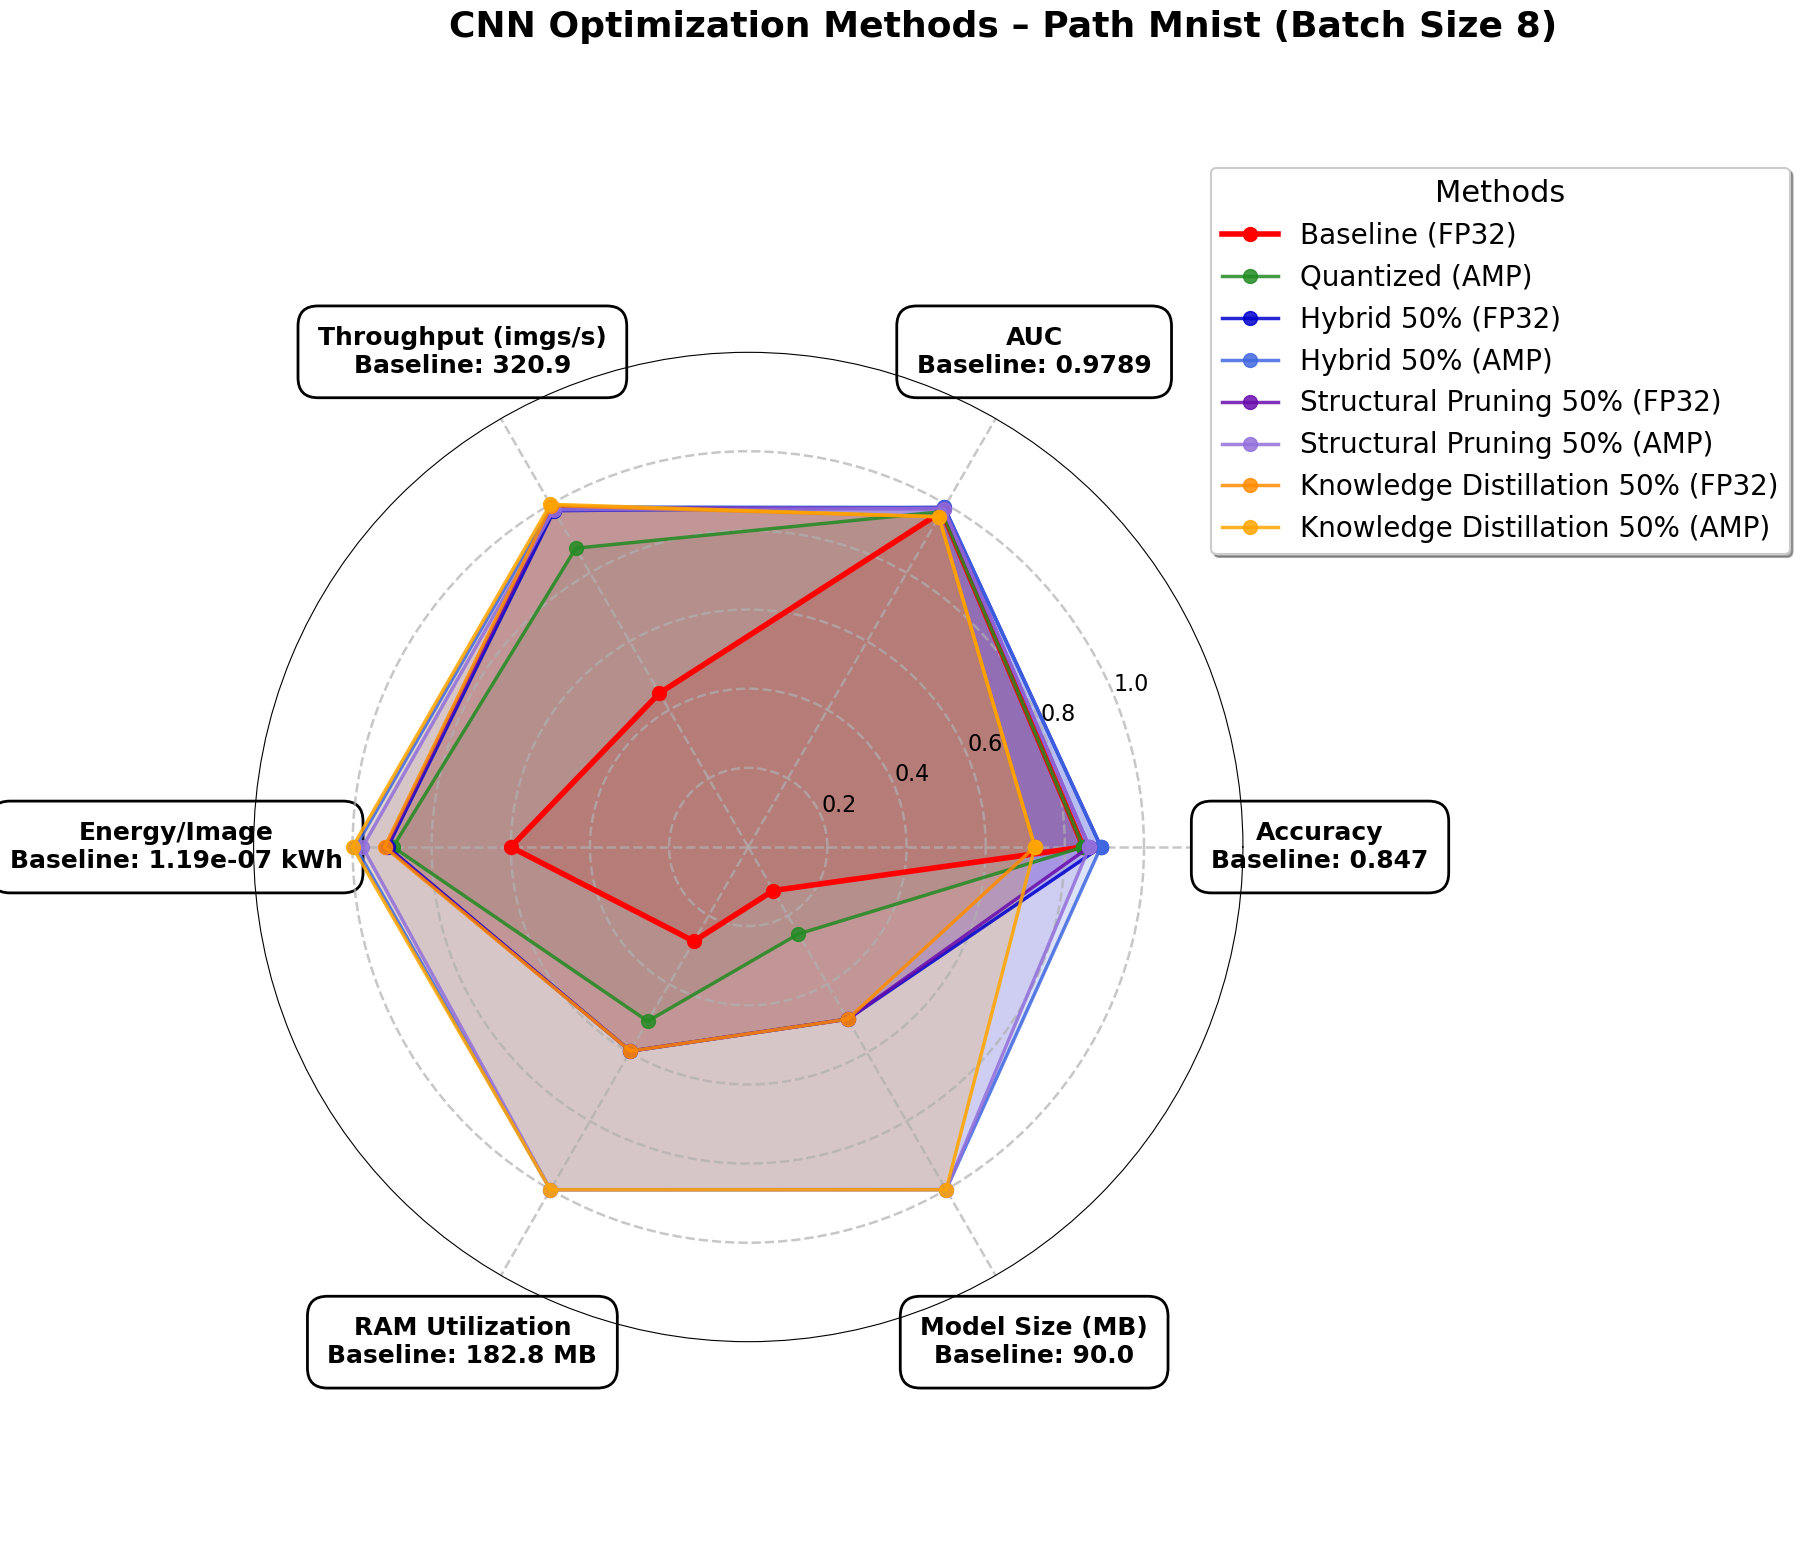


Performance Summary (Batch Size 8)
Model                                         Accuracy     AUC          Throughput      Energy/img      GPU RAM (MB)    Size (MB)   
--------------------------------------------------------------------------------------------------------------------------------------------
Baseline (FP32)                               0.8468       0.978889     320.86          1.19e-07        182.8           90.0        
Quantized (AMP)                               0.8465       0.978460     623.05          7.98e-08        98.9            45.1        
Hybrid 50% (FP32)                             0.8915       0.990933     701.36          7.86e-08        84.4            22.8        
Hybrid 50% (AMP)                              0.8910       0.990715     709.20          7.22e-08        50.3            11.4        
Structural Pruning 50% (FP32)                 0.8618       0.987532     707.16          7.83e-08        84.4            22.8        
Structural Pruning 50% (A

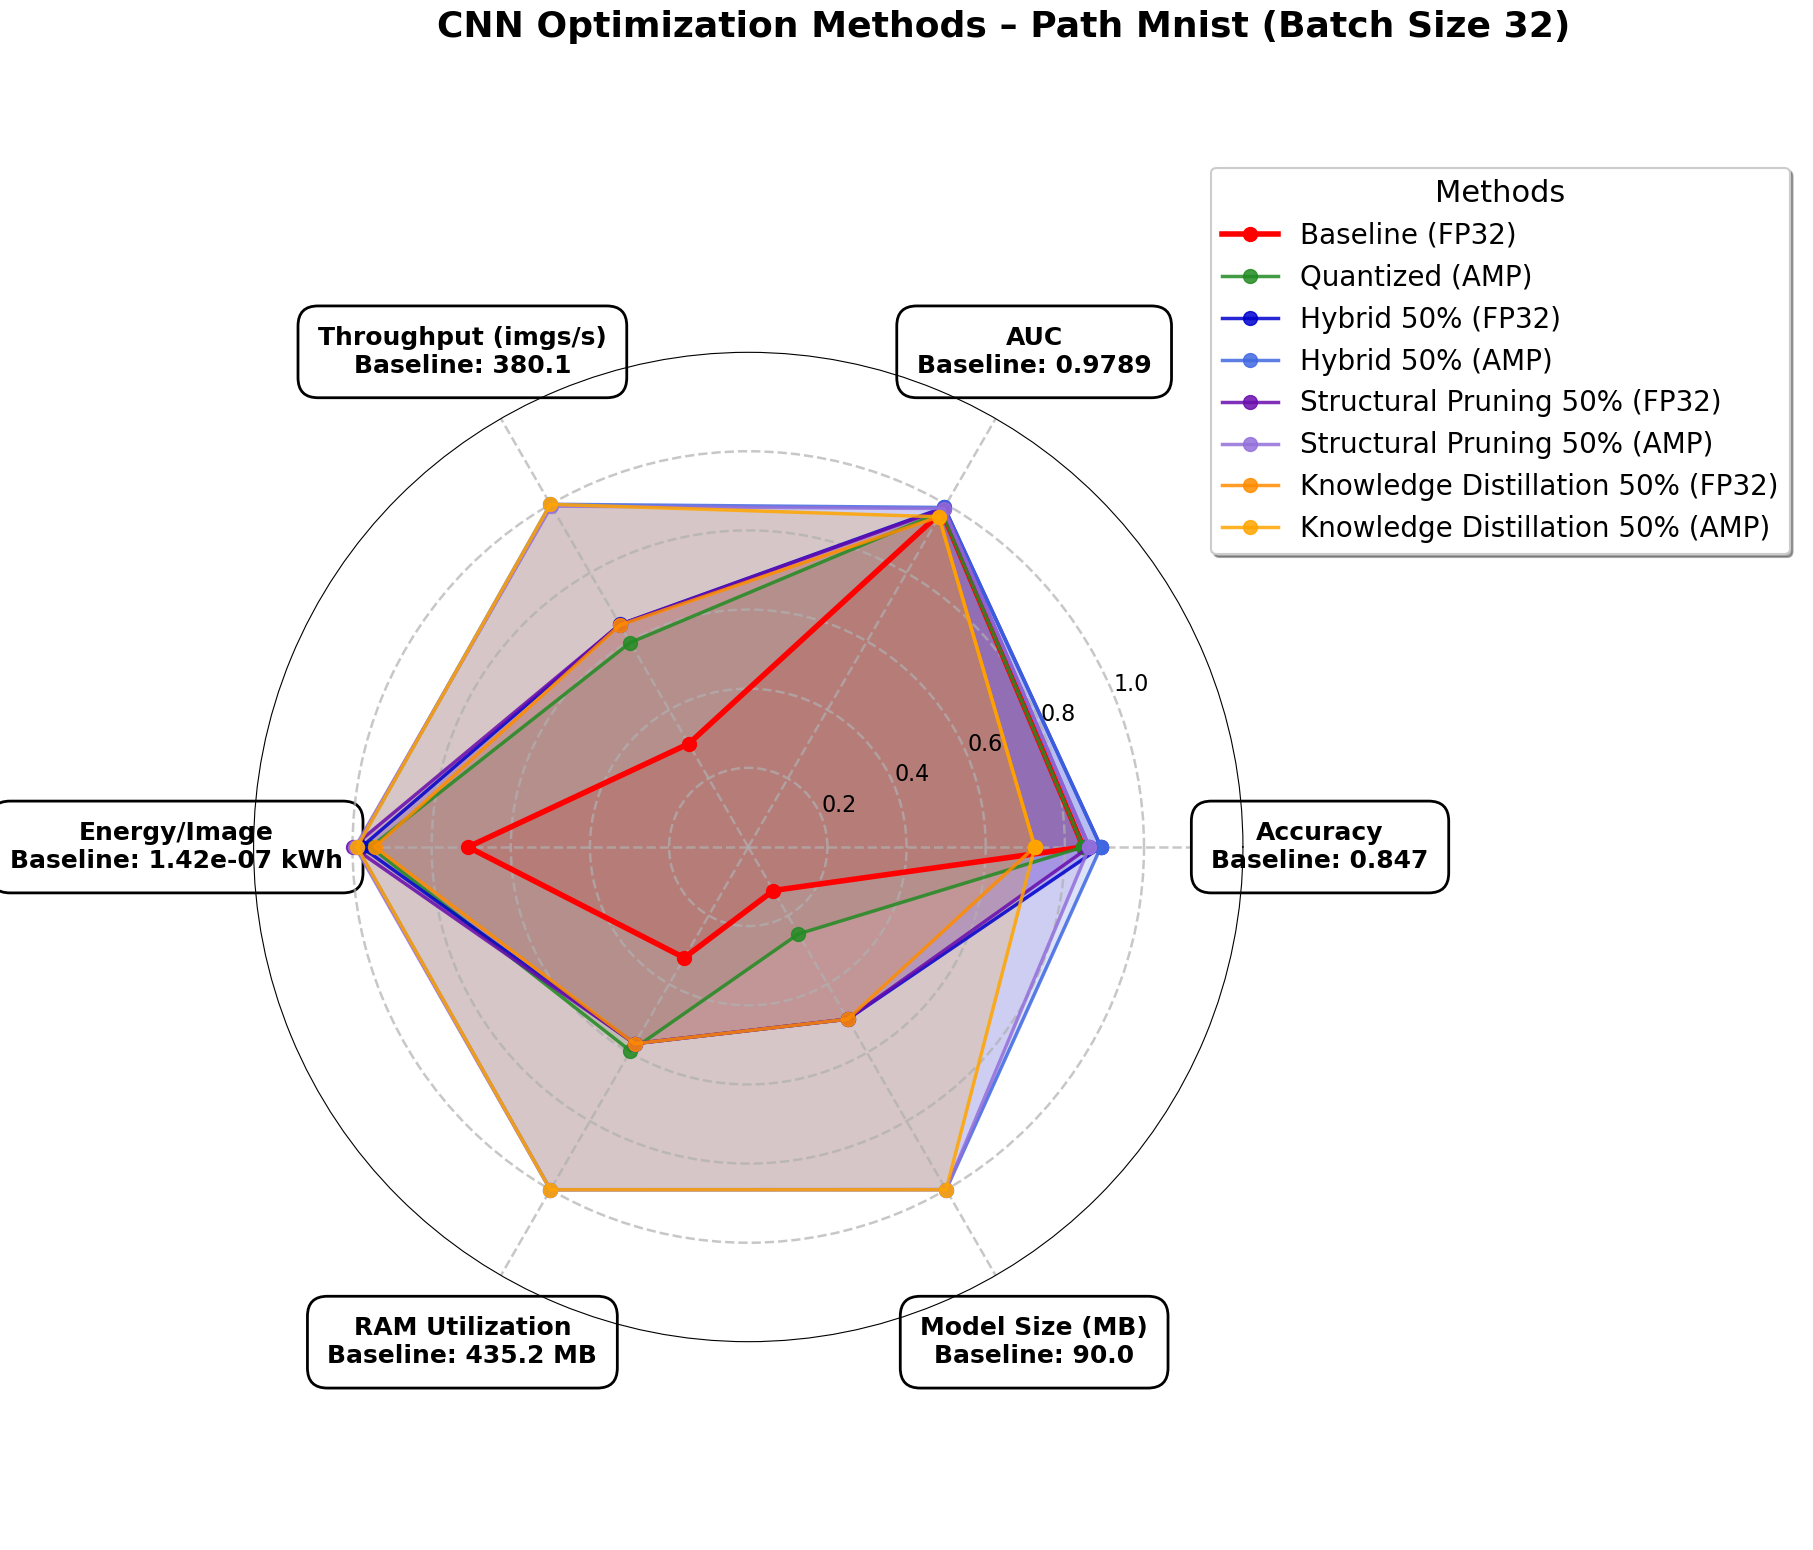


Performance Summary (Batch Size 32)
Model                                         Accuracy     AUC          Throughput      Energy/img      GPU RAM (MB)    Size (MB)   
--------------------------------------------------------------------------------------------------------------------------------------------
Baseline (FP32)                               0.8468       0.978889     380.14          1.42e-07        435.2           90.0        
Quantized (AMP)                               0.8465       0.978460     752.97          1.05e-07        236.4           45.1        
Hybrid 50% (FP32)                             0.8915       0.990933     819.62          1.03e-07        245.2           22.8        
Hybrid 50% (AMP)                              0.8910       0.990715     1262.32         1.01e-07        140.7           11.4        
Structural Pruning 50% (FP32)                 0.8618       0.987532     819.09          1.00e-07        245.2           22.8        
Structural Pruning 50% (

In [7]:
"""
Save CNN Model Performance Data to LaTeX Format and Generate Radar Plots

This script processes CSV data, generates radar plots, and saves raw metrics 
to LaTeX table format.

NORMALIZATION METHOD:
- Accuracy & AUC: Direct values (absolute, 0-1 scale)
- Throughput: (current/baseline) / max_ratio across all methods
- Energy: (baseline/current) / max_ratio - INVERTED so higher is better
- RAM: (baseline/current) / max_ratio - INVERTED so higher is better  
- Model Size: (baseline/current) / max_ratio - INVERTED so higher is better
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi
import os


def create_method_label(row):
    """Create display labels for each method variant."""
    method = row['pruning_method']
    precision = row['runtime_precision']
    sparsity = row['sparsity']
    
    if method == 'baseline' and precision == 'fp32':
        return 'Baseline (FP32)', 'baseline', 0
    elif method == 'quantization' and precision == 'amp':
        return 'Quantized (AMP)', 'quantization', 1
    elif method == 'hybrid_pruning' and precision == 'fp32':
        return f'Hybrid {sparsity} (FP32)', 'hybrid_pruning', 2
    elif method == 'hybrid_pruning_fp16' and precision == 'amp':
        return f'Hybrid {sparsity} (AMP)', 'hybrid_pruning_fp16', 3
    elif method == 'regional_pruning' and precision == 'fp32':
        return f'Structural Pruning {sparsity} (FP32)', 'regional_pruning', 4
    elif method == 'regional_pruning_fp16' and precision == 'amp':
        return f'Structural Pruning {sparsity} (AMP)', 'regional_pruning_fp16', 5
    elif method == 'slim_kd' and precision == 'fp32':
        return f'Knowledge Distillation {sparsity} (FP32)', 'slim_kd', 6
    elif method == 'slim_kd_fp16' and precision == 'amp':
        return f'Knowledge Distillation {sparsity} (AMP)', 'slim_kd_fp16', 7
    else:
        return f'{method} {precision}', 'other', 99


def get_method_color(label):
    """Get color for each method label"""
    color_map = {
        'Baseline (FP32)': '#FF0000',
        'Quantized (AMP)': '#228B22',
        'Hybrid 50% (FP32)': '#0000CD',
        'Hybrid 50% (AMP)': '#4169E1',
        'Structural Pruning 50% (FP32)': '#6A0DAD',
        'Structural Pruning 50% (AMP)': '#9370DB',
        'Knowledge Distillation 50% (FP32)': '#FF8C00',
        'Knowledge Distillation 50% (AMP)': '#FFA500',
    }
    return color_map.get(label, '#333333')


def save_data_to_latex(csv_path, output_dir='/Users/arihangupta/Downloads/pruning_project_data/CNN/Visuals', dataset_name='bloodmnist'):
    """Extract and save raw data to LaTeX format text files for manual plotting."""
    
    os.makedirs(output_dir, exist_ok=True)
    
    # Save normalization formulas document
    normalization_doc = os.path.join(output_dir, f'{dataset_name}_normalization_formulas.txt')
    with open(normalization_doc, 'w') as f:
        f.write("="*80 + "\n")
        f.write("RADAR PLOT NORMALIZATION FORMULAS\n")
        f.write(f"Dataset: {dataset_name}\n")
        f.write("="*80 + "\n\n")
        
        f.write("METRICS AND THEIR NORMALIZATION:\n")
        f.write("-"*80 + "\n\n")
        
        f.write("1. ACCURACY\n")
        f.write("   Formula: normalized_value = accuracy (direct value, 0-1 scale)\n")
        f.write("   Note: No baseline comparison\n\n")
        
        f.write("2. AUC (Area Under Curve)\n")
        f.write("   Formula: normalized_value = AUC (direct value, 0-1 scale)\n")
        f.write("   Note: No baseline comparison\n\n")
        
        f.write("3. THROUGHPUT\n")
        f.write("   Step 1: ratio = current_throughput / baseline_throughput\n")
        f.write("   Step 2: max_ratio = max(all ratios across methods)\n")
        f.write("   Step 3: normalized_value = min(ratio / max_ratio, 1.0)\n")
        f.write("   Direction: Higher is better\n\n")
        
        f.write("4. ENERGY PER IMAGE\n")
        f.write("   Step 1: ratio = baseline_energy / current_energy [INVERTED]\n")
        f.write("   Step 2: max_ratio = max(all ratios across methods)\n")
        f.write("   Step 3: normalized_value = min(ratio / max_ratio, 1.0)\n")
        f.write("   Direction: Higher is better (inverted so lower energy = higher value)\n")
        f.write("   Note: Equivalent to min(energy) / current_energy after normalization\n\n")
        
        f.write("5. RAM UTILIZATION\n")
        f.write("   Step 1: ratio = baseline_ram / current_ram [INVERTED]\n")
        f.write("   Step 2: max_ratio = max(all ratios across methods)\n")
        f.write("   Step 3: normalized_value = min(ratio / max_ratio, 1.0)\n")
        f.write("   Direction: Higher is better (inverted so lower RAM = higher value)\n")
        f.write("   Note: Equivalent to min(ram) / current_ram after normalization\n\n")
        
        f.write("6. MODEL SIZE\n")
        f.write("   Step 1: ratio = baseline_size / current_size [INVERTED]\n")
        f.write("   Step 2: max_ratio = max(all ratios across methods)\n")
        f.write("   Step 3: normalized_value = min(ratio / max_ratio, 1.0)\n")
        f.write("   Direction: Higher is better (inverted so smaller size = higher value)\n")
        f.write("   Note: Equivalent to min(size) / current_size after normalization\n\n")
        
        f.write("="*80 + "\n")
        f.write("MATHEMATICAL EQUIVALENCE\n")
        f.write("="*80 + "\n\n")
        
        f.write("For inverted metrics (Energy, RAM, Size):\n")
        f.write("  (baseline/current) / max(baseline/current)\n")
        f.write("= (baseline/current) / (baseline/min(current))\n")
        f.write("= min(current) / current\n\n")
        
        f.write("Therefore, the normalization is equivalent to:\n")
        f.write("  normalized_value = best_value / current_value\n\n")
        
        f.write("Where best_value = minimum across all methods for that metric\n")
        f.write("(minimum energy, minimum RAM, minimum size)\n\n")
        
        f.write("="*80 + "\n")
        f.write("INTERPRETATION\n")
        f.write("="*80 + "\n\n")
        
        f.write("- All normalized values range from 0 to 1.0\n")
        f.write("- The best-performing method on each axis = 1.0\n")
        f.write("- Values closer to 1.0 = better performance on that metric\n")
        f.write("- Baseline may NOT be at 1.0 (only if baseline is best on that metric)\n")
        f.write("- Each method is compared to the best performer, not necessarily baseline\n\n")
    
    print(f"Normalization formulas saved to: {normalization_doc}")
    
    df = pd.read_csv(csv_path)
    print(f"Loaded CSV with {len(df)} rows")
    
    if 'batch_size' not in df.columns:
        raise KeyError("'batch_size' column not found in CSV")
    
    df[['method_label', 'method_group', 'sort_order']] = df.apply(
        lambda row: pd.Series(create_method_label(row)), axis=1
    )
    
    if df['Acc'].max() > 1.5:
        df['Acc'] = df['Acc'] / 100.0
    if df['AUC'].max() > 1.5:
        df['AUC'] = df['AUC'] / 100.0
    
    df['energy_kWh_per_image'] = df['energy_kWh_per_image'].replace(0, np.nan)
    df['peak_gpu_mem_MB'] = df['peak_gpu_mem_MB'].replace(0, np.nan)
    df['ModelSizeMB'] = df['ModelSizeMB'].replace(0, np.nan)
    
    batch_sizes = sorted(df['batch_size'].unique())
    
    for batch_size in batch_sizes:
        print(f"\n{'='*60}")
        print(f"Processing Batch Size {batch_size}")
        print(f"{'='*60}")
        
        batch_df = df[df['batch_size'] == batch_size].copy()
        
        if batch_df.empty:
            continue
        
        baseline_candidates = batch_df[batch_df['method_label'] == 'Baseline (FP32)']
        
        if baseline_candidates.empty:
            continue
        
        baseline = baseline_candidates.sort_values('Acc', ascending=False).iloc[0]
        
        # Calculate ratios relative to baseline
        batch_df['throughput_ratio'] = batch_df['throughput_imgs_per_s'] / baseline['throughput_imgs_per_s']
        batch_df['energy_ratio'] = baseline['energy_kWh_per_image'] / batch_df['energy_kWh_per_image']
        batch_df['ram_ratio'] = baseline['peak_gpu_mem_MB'] / batch_df['peak_gpu_mem_MB']
        batch_df['modelsize_ratio'] = baseline['ModelSizeMB'] / batch_df['ModelSizeMB']
        
        max_acc = 1.0
        max_auc = 1.0
        max_throughput_ratio = batch_df['throughput_ratio'].max()
        max_energy_ratio = batch_df['energy_ratio'].max()
        max_ram_ratio = batch_df['ram_ratio'].max()
        max_modelsize_ratio = batch_df['modelsize_ratio'].max()
        
        models_to_plot = []
        
        for _, row in batch_df.iterrows():
            label = row['method_label']
            
            acc = row['Acc']
            auc = row['AUC']
            throughput = row['throughput_imgs_per_s']
            energy = row['energy_kWh_per_image']
            ram = row['peak_gpu_mem_MB']
            modelsize = row['ModelSizeMB']
            
            if pd.isna(acc) or pd.isna(auc) or pd.isna(throughput) or pd.isna(energy) or pd.isna(ram) or pd.isna(modelsize):
                continue
            
            normalized_values = []
            normalized_values.append(acc / max_acc)
            normalized_values.append(auc / max_auc)
            
            throughput_ratio = throughput / baseline['throughput_imgs_per_s']
            normalized_values.append(min(throughput_ratio / max_throughput_ratio, 1.0))
            
            energy_ratio = baseline['energy_kWh_per_image'] / energy
            normalized_values.append(min(energy_ratio / max_energy_ratio, 1.0))
            
            ram_ratio = baseline['peak_gpu_mem_MB'] / ram
            normalized_values.append(min(ram_ratio / max_ram_ratio, 1.0))
            
            modelsize_ratio = baseline['ModelSizeMB'] / modelsize
            normalized_values.append(min(modelsize_ratio / max_modelsize_ratio, 1.0))
            
            models_to_plot.append({
                'label': label,
                'values': normalized_values,
                'raw_values': {
                    'Acc': acc,
                    'AUC': auc,
                    'Throughput': throughput,
                    'Energy': energy,
                    'RAM': ram,
                    'ModelSize': modelsize
                },
                'sort_order': row['sort_order']
            })
        
        models_to_plot.sort(key=lambda x: x['sort_order'])
        
        # Create LaTeX file with raw data
        latex_filename = os.path.join(output_dir, f'{dataset_name}_batch{batch_size}_data.tex')
        
        with open(latex_filename, 'w') as f:
            # Write header with normalization explanation
            f.write("% Raw data for radar chart\n")
            f.write(f"% Dataset: {dataset_name}, Batch Size: {batch_size}\n\n")
            f.write("% NORMALIZATION METHODOLOGY:\n")
            f.write("% - Accuracy & AUC: Direct absolute values (0-1 scale)\n")
            f.write("% - Throughput: (current/baseline) / max_throughput_ratio\n")
            f.write("%   where max_throughput_ratio = max((current/baseline)) across all methods\n")
            f.write("% - Energy: (baseline/current) / max_energy_ratio [INVERTED - higher is better]\n")
            f.write("%   where max_energy_ratio = max((baseline/current)) across all methods\n")
            f.write("% - RAM: (baseline/current) / max_ram_ratio [INVERTED - higher is better]\n")
            f.write("%   where max_ram_ratio = max((baseline/current)) across all methods\n")
            f.write("% - Model Size: (baseline/current) / max_modelsize_ratio [INVERTED - higher is better]\n")
            f.write("%   where max_modelsize_ratio = max((baseline/current)) across all methods\n\n")
            
            # Write baseline values
            f.write("% Baseline Values\n")
            f.write("\\begin{table}[h]\n")
            f.write("\\centering\n")
            f.write("\\begin{tabular}{ll}\n")
            f.write("\\toprule\n")
            f.write("Metric & Value \\\\\n")
            f.write("\\midrule\n")
            f.write(f"Accuracy & {baseline['Acc']:.4f} \\\\\n")
            f.write(f"AUC & {baseline['AUC']:.6f} \\\\\n")
            f.write(f"Throughput (img/s) & {baseline['throughput_imgs_per_s']:.2f} \\\\\n")
            f.write(f"Energy (kWh/img) & {baseline['energy_kWh_per_image']:.2e} \\\\\n")
            f.write(f"Peak GPU RAM (MB) & {baseline['peak_gpu_mem_MB']:.1f} \\\\\n")
            f.write(f"Model Size (MB) & {baseline['ModelSizeMB']:.1f} \\\\\n")
            f.write("\\bottomrule\n")
            f.write("\\end{tabular}\n")
            f.write("\\caption{Baseline Values}\n")
            f.write("\\end{table}\n\n")
            
            # Write raw metrics table
            f.write("% Raw Metrics for All Models\n")
            f.write("\\begin{table}[h]\n")
            f.write("\\centering\n")
            f.write("\\small\n")
            f.write("\\begin{tabular}{lcccccc}\n")
            f.write("\\toprule\n")
            f.write("Method & Acc & AUC & Throughput & Energy & GPU RAM & Size \\\\\n")
            f.write(" & & & (img/s) & (kWh/img) & (MB) & (MB) \\\\\n")
            f.write("\\midrule\n")
            
            for model in models_to_plot:
                raw = model['raw_values']
                # Escape special characters for LaTeX
                method_name = model['label'].replace('_', '\\_').replace('%', '\\%').replace('&', '\\&')
                f.write(f"{method_name} & {raw['Acc']:.4f} & {raw['AUC']:.6f} & "
                       f"{raw['Throughput']:.2f} & {raw['Energy']:.2e} & "
                       f"{raw['RAM']:.1f} & {raw['ModelSize']:.1f} \\\\\n")
            
            f.write("\\bottomrule\n")
            f.write("\\end{tabular}\n")
            f.write("\\caption{Raw Performance Metrics}\n")
            f.write("\\end{table}\n\n")
            
            # Write normalized values table with explanation
            f.write("% Normalized Values for Radar Plot (0-1 scale)\n")
            f.write("% Note: For Energy, RAM, and Size - values are INVERTED (baseline/current)\n")
            f.write("% so that higher values on the chart indicate better performance\n")
            f.write("\\begin{table}[h]\n")
            f.write("\\centering\n")
            f.write("\\small\n")
            f.write("\\begin{tabular}{lcccccc}\n")
            f.write("\\toprule\n")
            f.write("Method & Acc & AUC & Throughput & Energy & RAM & Size \\\\\n")
            f.write(" & (abs) & (abs) & (cur/base) & (base/cur) & (base/cur) & (base/cur) \\\\\n")
            f.write("\\midrule\n")
            
            for model in models_to_plot:
                method_name = model['label'].replace('_', '\\_').replace('%', '\\%').replace('&', '\\&')
                vals = model['values']
                f.write(f"{method_name} & {vals[0]:.4f} & {vals[1]:.4f} & "
                       f"{vals[2]:.4f} & {vals[3]:.4f} & {vals[4]:.4f} & {vals[5]:.4f} \\\\\n")
            
            f.write("\\bottomrule\n")
            f.write("\\end{tabular}\n")
            f.write("\\caption{Normalized Values for Radar Chart (Baseline = 1.0 for throughput; inverted for efficiency metrics)}\n")
            f.write("\\end{table}\n\n")
            
            # Write scaling factors with clear explanation
            f.write("% Scaling Factors and Normalization Details\n")
            f.write("\\begin{table}[h]\n")
            f.write("\\centering\n")
            f.write("\\begin{tabular}{lll}\n")
            f.write("\\toprule\n")
            f.write("Metric & Calculation & Max Ratio \\\\\n")
            f.write("\\midrule\n")
            f.write(f"Accuracy & Direct value & {max_acc:.4f} (absolute) \\\\\n")
            f.write(f"AUC & Direct value & {max_auc:.6f} (absolute) \\\\\n")
            f.write(f"Throughput & (current/baseline) / max\\_ratio & {max_throughput_ratio:.2f}x \\\\\n")
            f.write(f"Energy & (baseline/current) / max\\_ratio & {max_energy_ratio:.2f}x (inverted) \\\\\n")
            f.write(f"RAM & (baseline/current) / max\\_ratio & {max_ram_ratio:.2f}x (inverted) \\\\\n")
            f.write(f"Model Size & (baseline/current) / max\\_ratio & {max_modelsize_ratio:.2f}x (inverted) \\\\\n")
            f.write("\\bottomrule\n")
            f.write("\\end{tabular}\n")
            f.write("\\caption{Scaling Factors (inverted means baseline/current for efficiency)}\n")
            f.write("\\end{table}\n\n")
            
            # Write Python/JSON-like data for easy parsing
            f.write("% Python-readable format for plotting\n")
            f.write("% NORMALIZATION:\n")
            f.write("% Acc, AUC: absolute values\n")
            f.write("% Throughput: ratio to baseline, then normalized by max ratio\n")
            f.write("% Energy, RAM, Size: INVERTED (baseline/current), then normalized by max ratio\n")
            f.write("% models = [\n")
            for model in models_to_plot:
                f.write(f"%   {{\n")
                f.write(f"%     'label': '{model['label']}',\n")
                f.write(f"%     'normalized': {model['values']},\n")
                raw = model['raw_values']
                f.write(f"%     'raw': {{'Acc': {raw['Acc']:.4f}, 'AUC': {raw['AUC']:.6f}, ")
                f.write(f"'Throughput': {raw['Throughput']:.2f}, 'Energy': {raw['Energy']:.2e}, ")
                f.write(f"'RAM': {raw['RAM']:.1f}, 'ModelSize': {raw['ModelSize']:.1f}}}\n")
                f.write(f"%   }},\n")
            f.write("% ]\n")
        
        print(f"LaTeX data file saved to: {latex_filename}")
        
        # ------------------------------------------------------------------
        # RADAR PLOT – BIG FONTS, NO OVERLAP
        # ------------------------------------------------------------------
        num_vars = 6
        angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
        angles += angles[:1]

        # 1. Make the canvas huge
        fig = plt.figure(figsize=(20, 18), constrained_layout=False)

        # 2. Polar subplot + dedicated legend column
        gs = fig.add_gridspec(1, 2, width_ratios=[3, 1], wspace=0.35)
        ax = fig.add_subplot(gs[0, 0], projection='polar')

        # ------------------------------------------------------------------
        # Plot each model
        # ------------------------------------------------------------------
        for idx, model_data in enumerate(models_to_plot):
            values = model_data['values'] + model_data['values'][:1]
            linewidth = 4 if 'Baseline' in model_data['label'] else 2.5
            alpha_line = 1.0 if 'Baseline' in model_data['label'] else 0.85
            alpha_fill = 0.30 if 'Baseline' in model_data['label'] else 0.18
            color = get_method_color(model_data['label'])

            ax.plot(angles, values, 'o-', linewidth=linewidth,
                    label=model_data['label'], color=color,
                    markersize=10, alpha=alpha_line)
            ax.fill(angles, values, alpha=alpha_fill, color=color)

        # ------------------------------------------------------------------
        # Axis labels – BIG, boxed, far from rim
        # ------------------------------------------------------------------
        ax.set_xticks(angles[:-1])
        axis_labels = [
            f"Accuracy\nBaseline: {baseline['Acc']:.3f}",
            f"AUC\nBaseline: {baseline['AUC']:.4f}",
            f"Throughput (imgs/s)\nBaseline: {baseline['throughput_imgs_per_s']:.1f}",
            f"Energy/Image\nBaseline: {baseline['energy_kWh_per_image']:.2e} kWh",
            f"RAM Utilization\nBaseline: {baseline['peak_gpu_mem_MB']:.1f} MB",
            f"Model Size (MB)\nBaseline: {baseline['ModelSizeMB']:.1f}"
        ]

        for lbl in ax.set_xticklabels(axis_labels):
            lbl.set_fontsize(18)
            lbl.set_fontweight('bold')
            lbl.set_ha('center')
            lbl.set_va('center')
            lbl.set_bbox(dict(boxstyle='round,pad=0.8',
                              facecolor='white', edgecolor='black',
                              linewidth=2, alpha=1.0))

        ax.tick_params(axis='x', pad=45)  # push labels outward

        # ------------------------------------------------------------------
        # Radial ticks – BIG
        # ------------------------------------------------------------------
        ax.set_ylim(0, 1.25)
        ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
        ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=16)
        ax.grid(True, linestyle='--', alpha=0.7, linewidth=1.8)

        # ------------------------------------------------------------------
        # Title – BIG
        # ------------------------------------------------------------------
        dataset_display = dataset_name.replace('mnist', ' MNIST').title()
        fig.suptitle(f'CNN Optimization Methods – {dataset_display} '
                     f'(Batch Size {batch_size})',
                     fontsize=26, fontweight='bold', y=0.96)

        # ------------------------------------------------------------------
        # Legend – dedicated column, BIG
        # ------------------------------------------------------------------
        leg_ax = fig.add_subplot(gs[0, 1])
        leg_ax.axis('off')

        legend = leg_ax.legend(
            *ax.get_legend_handles_labels(),
            loc='upper right',            # within the legend axis
            bbox_to_anchor=(1, 1),        # move it to top right
            fontsize=20,
            frameon=True,
            fancybox=True,
            shadow=True,
            ncol=1,
            title='Methods',
            title_fontsize=22
        )
        legend.get_frame().set_linewidth(1.5)



        # ------------------------------------------------------------------
        # Save
        # ------------------------------------------------------------------
        plot_filename = os.path.join(output_dir,
                        f'cnn_radar_{dataset_name}_batch{batch_size}_BIGFONT.png')
        plt.savefig(plot_filename, dpi=300, bbox_inches='tight', pad_inches=1.0)
        print(f"Radar plot (BIG FONTS) saved to: {plot_filename}")

        plt.show()
        plt.close()
        
        # Print summary to console with normalization info
        print(f"\nPerformance Summary (Batch Size {batch_size})")
        print("="*140)
        print(f"{'Model':<45} {'Accuracy':<12} {'AUC':<12} {'Throughput':<15} {'Energy/img':<15} {'GPU RAM (MB)':<15} {'Size (MB)':<12}")
        print("-"*140)
        
        for model in models_to_plot:
            raw = model['raw_values']
            print(f"{model['label']:<45} {raw['Acc']:<12.4f} {raw['AUC']:<12.6f} "
                  f"{raw['Throughput']:<15.2f} {raw['Energy']:<15.2e} {raw['RAM']:<15.1f} {raw['ModelSize']:<12.1f}")
        print("="*140)
        
        # Print normalization details
        print(f"\nNormalization Details for Batch Size {batch_size}:")
        print("-"*80)
        print(f"Max Throughput Ratio: {max_throughput_ratio:.3f}x baseline")
        print(f"Max Energy Ratio: {max_energy_ratio:.3f}x (baseline/current - inverted)")
        print(f"Max RAM Ratio: {max_ram_ratio:.3f}x (baseline/current - inverted)")
        print(f"Max Size Ratio: {max_modelsize_ratio:.3f}x (baseline/current - inverted)")
        print("-"*80)
        
        # Print formulas
        print("\nNORMALIZATION FORMULAS:")
        print("-"*80)
        print("Accuracy:    value (direct)")
        print("AUC:         value (direct)")
        print("Throughput:  (current/baseline) / max_ratio")
        print("Energy:      (baseline/current) / max_ratio  [INVERTED]")
        print("RAM:         (baseline/current) / max_ratio  [INVERTED]")
        print("Size:        (baseline/current) / max_ratio  [INVERTED]")
        print("-"*80)
        print("Note: Inverted metrics equivalent to min(metric)/current after normalization")
        print("="*80)


if __name__ == "__main__":
    base_dir = "/Users/arihangupta/Downloads/pruning_project_data/CNN"
    output_dir = os.path.join(base_dir, "Visuals")
    
    datasets = {
        'bloodmnist': os.path.join(base_dir, "merged_results/bloodmnist_averaged_results.csv"),
        'dermamnist': os.path.join(base_dir, "merged_results/dermamnist_averaged_results.csv"),
        'pathmnist': os.path.join(base_dir, "merged_results/pathmnist_averaged_results.csv")
    }
    
    for dataset_name, csv_path in datasets.items():
        print(f"\n{'#'*80}")
        print(f"# Processing {dataset_name.upper()}")
        print(f"{'#'*80}")
        
        try:
            save_data_to_latex(csv_path, output_dir=output_dir, dataset_name=dataset_name)
        except Exception as e:
            print(f"Error processing {dataset_name}: {e}")
            continue

CNN Visualization script with separated break-even graphs and LaTeX tables

In [1]:
"""
CNN Visualization script with separated break-even graphs and LaTeX tables
Updated method names: Regional Pruning → Structured Pruning, Slim KD → Knowledge Distillation

UPDATED: Works with *_averaged_results.csv files
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

def create_output_directories(base_path):
    """Create output directories for saving plots"""
    output_path = Path(base_path) / 'visualization_outputs_cnn'
    datasets = ['bloodmnist', 'dermamnist', 'pathmnist']
    
    # Create main output directory
    output_path.mkdir(exist_ok=True)
    
    # Create subdirectories for each dataset
    for dataset in datasets:
        (output_path / dataset).mkdir(exist_ok=True)
    
    return output_path

def load_merged_data(merged_dir):
    """Load data from individual averaged CSV files"""
    merged_path = Path(merged_dir)
    all_data = []
    
    # Look for averaged results CSV files
    csv_files = list(merged_path.glob('*_averaged_results.csv'))
    print(f"Found CSV files: {[f.name for f in csv_files]}")
    
    for csv_file in csv_files:
        # Extract dataset name from filename
        dataset_name = csv_file.stem.replace('_averaged_results', '')
        print(f"Loading {dataset_name} data from {csv_file.name}")
        
        df = pd.read_csv(csv_file)
        df['dataset'] = dataset_name
        all_data.append(df)
        print(f"  Loaded {len(df)} records for {dataset_name}")
    
    # Combine all datasets
    combined_df = pd.concat(all_data, ignore_index=True) if all_data else pd.DataFrame()
    print(f"\nTotal combined records: {len(combined_df)}")
    
    return combined_df

def get_display_method_name(method):
    """Convert internal method names to display names"""
    name_map = {
        'baseline': 'Baseline',
        'quantization': 'Quantization',
        'regional_pruning': 'Structured Pruning',
        'regional_pruning_fp16': 'Structured Pruning FP16',
        'slim_kd': 'Knowledge Distillation',
        'slim_kd_fp16': 'Knowledge Distillation FP16',
        'hybrid_pruning': 'Hybrid',
        'hybrid_pruning_fp16': 'Hybrid FP16'
    }
    return name_map.get(method, method)

def get_method_color(method):
    """Get color for each method"""
    color_map = {
        'baseline': '#000000',  # Black
        'quantization': '#808080',  # Gray
        'regional_pruning': '#8B0000',  # Dark red
        'regional_pruning_fp16': '#FF6B6B',  # Light red
        'slim_kd': '#000080',  # Dark blue
        'slim_kd_fp16': '#6B6BFF',  # Light blue
        'hybrid_pruning': '#4B0082',  # Dark purple
        'hybrid_pruning_fp16': '#9370DB'  # Light purple
    }
    return color_map.get(method, '#333333')

def get_method_groups():
    """Define method groupings for plotting"""
    return [
        ['baseline', 'quantization'],
        ['slim_kd', 'slim_kd_fp16'], 
        ['regional_pruning', 'regional_pruning_fp16'],
        ['hybrid_pruning', 'hybrid_pruning_fp16']
    ]

def get_group_display_name(group):
    """Get display name for method group"""
    if group[0] == 'baseline':
        return 'Baseline Methods'
    elif group[0] == 'slim_kd':
        return 'Knowledge Distillation'
    elif group[0] == 'regional_pruning':
        return 'Structured Pruning'
    elif group[0] == 'hybrid_pruning':
        return 'Hybrid'
    return group[0]

def format_value_for_label(value, metric_name=None):
    """Format value for bar label based on its magnitude"""
    if pd.isna(value):
        return 'N/A'
    
    if abs(value) < 1e-5:
        return f'{value:.2e}'
    elif abs(value) < 1e-3:
        return f'{value:.1e}'
    elif abs(value) < 0.01:
        return f'{value:.4f}'
    elif abs(value) < 1:
        return f'{value:.3f}'
    elif abs(value) < 10:
        return f'{value:.2f}'
    elif abs(value) < 100:
        return f'{value:.1f}'
    elif abs(value) < 10000:
        return f'{value:.0f}'
    else:
        return f'{value:.2e}'

def plot_grouped_bars(ax, data_dict, ylabel, title, show_values=False, y_limits=None):
    """Create grouped bar plot with proper spacing"""
    
    method_groups = get_method_groups()
    
    x_pos = 0
    x_ticks = []
    x_labels = []
    bar_width = 0.35
    group_spacing = 0.8
    
    for group in method_groups:
        group_start = x_pos
        group_bars = []
        
        for i, method in enumerate(group):
            if method in data_dict:
                value = data_dict[method]
                if value is not None and not pd.isna(value):
                    color = get_method_color(method)
                    bar = ax.bar(x_pos, value, bar_width, color=color, alpha=0.8)
                    group_bars.append(bar)
                    
                    # Add value labels for specific metrics
                    if show_values:
                        label_text = format_value_for_label(value)
                        fontsize = 8 if len(label_text) > 6 else 9
                        ax.text(x_pos, value * 1.02 if value > 0 else 0, label_text,
                               ha='center', va='bottom', fontsize=fontsize, fontweight='bold')
                    
                    x_pos += bar_width
        
        # Add group label at center
        if group_bars:
            group_center = group_start + (len(group_bars) - 1) * bar_width / 2
            x_ticks.append(group_center)
            x_labels.append(get_group_display_name(group))
        
        x_pos += group_spacing
    
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, fontsize=11)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Set y-axis limits if provided
    if y_limits:
        ax.set_ylim(y_limits)

def check_if_values_same_across_batch_sizes(df, dataset, metric):
    """Check if metric values are the same across batch sizes for a dataset"""
    dataset_data = df[df['dataset'] == dataset]
    
    # Group by pruning method and check if values are the same across batch sizes
    same_values = True
    for method in dataset_data['pruning_method'].unique():
        method_data = dataset_data[dataset_data['pruning_method'] == method]
        if len(method_data) > 1:
            # Check if values are the same (within tolerance)
            values = method_data[metric].dropna()
            if len(values) > 0:
                if values.max() - values.min() > 1e-5:  # Tolerance for floating point comparison
                    same_values = False
                    break
    
    return same_values

def get_y_limits_for_metric(dataset_data, metric_col):
    """Calculate appropriate y-limits for a metric across all batch sizes"""
    valid_values = dataset_data[metric_col].dropna()
    if valid_values.empty:
        return None
    
    min_val = valid_values.min()
    max_val = valid_values.max()
    
    # Special handling for accuracy/AUC
    if metric_col in ['Acc', 'AUC']:
        min_val = max(0.5, min_val * 0.95)
        padding = (max_val - min_val) * 0.1
        return (min_val, max_val + padding)
    
    # Add some padding (10% on each side)
    range_val = max_val - min_val
    if range_val == 0:
        # If all values are the same, add some padding around the value
        padding = abs(min_val) * 0.1 if min_val != 0 else 1
        return (min_val - padding, max_val + padding)
    else:
        padding = range_val * 0.1
        return (max(0, min_val - padding), max_val + padding)

def plot_metric_for_dataset(df, dataset, metric_dict, output_path):
    """Plot a metric for a dataset - single plot if values same across batch sizes, dual if different"""
    
    dataset_data = df[df['dataset'] == dataset].copy()
    if dataset_data.empty:
        print(f"    No data for {dataset}")
        return
    
    metric_col = metric_dict['column']
    
    # Check if metric exists in data
    if metric_col not in dataset_data.columns:
        print(f"    Column '{metric_col}' not found for {dataset}")
        return
    
    # Check if values are the same across batch sizes
    same_across_batches = check_if_values_same_across_batch_sizes(df, dataset, metric_col)
    
    if same_across_batches:
        # Single plot - use batch size 8 data (or first available batch size)
        available_batch_sizes = sorted(dataset_data['batch_size'].unique())
        data_subset = dataset_data[dataset_data['batch_size'] == available_batch_sizes[0]]
        
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        
        # Create data dictionary
        data_dict = {}
        for _, row in data_subset.iterrows():
            method = row['pruning_method']
            value = row[metric_col]
            if not pd.isna(value):
                data_dict[method] = value
        
        if not data_dict:
            print(f"    No valid data for {metric_col} in {dataset}")
            plt.close()
            return
        
        y_limits = get_y_limits_for_metric(dataset_data, metric_col)
        show_values = metric_dict.get('show_values', False)
        plot_grouped_bars(ax, data_dict, metric_dict['ylabel'], 
                         f"{dataset.replace('mnist', '').title()} - {metric_dict['title']}", 
                         show_values=show_values, y_limits=y_limits)
        
        plt.tight_layout()
        plt.savefig(output_path / dataset / f"{metric_col}_{dataset}.png", 
                   dpi=300, bbox_inches='tight')
        plt.close()
        print(f"    Saved single plot: {metric_col}_{dataset}.png")
        
    else:
        # Dual plot - separate for each batch size with SAME Y-AXIS SCALE
        batch_sizes = sorted(dataset_data['batch_size'].unique())
        
        if len(batch_sizes) < 2:
            print(f"    Only one batch size available for {dataset}, creating single plot")
            # Fall back to single plot
            data_subset = dataset_data[dataset_data['batch_size'] == batch_sizes[0]]
            
            fig, ax = plt.subplots(1, 1, figsize=(10, 6))
            
            data_dict = {}
            for _, row in data_subset.iterrows():
                method = row['pruning_method']
                value = row[metric_col]
                if not pd.isna(value):
                    data_dict[method] = value
            
            if data_dict:
                y_limits = get_y_limits_for_metric(dataset_data, metric_col)
                show_values = metric_dict.get('show_values', False)
                plot_grouped_bars(ax, data_dict, metric_dict['ylabel'], 
                                 f"{dataset.replace('mnist', '').title()} - {metric_dict['title']}", 
                                 show_values=show_values, y_limits=y_limits)
                
                plt.tight_layout()
                plt.savefig(output_path / dataset / f"{metric_col}_{dataset}.png", 
                           dpi=300, bbox_inches='tight')
                plt.close()
                print(f"    Saved single plot: {metric_col}_{dataset}.png")
            else:
                plt.close()
            return
        
        # Calculate y-limits across ALL batch sizes to ensure same scale
        y_limits = get_y_limits_for_metric(dataset_data, metric_col)
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        for idx, batch_size in enumerate(batch_sizes[:2]):  # Only take first 2 batch sizes
            ax = axes[idx]
            data_subset = dataset_data[dataset_data['batch_size'] == batch_size]
            
            # Create data dictionary
            data_dict = {}
            for _, row in data_subset.iterrows():
                method = row['pruning_method']
                value = row[metric_col]
                if not pd.isna(value):
                    data_dict[method] = value
            
            if data_dict:
                show_values = metric_dict.get('show_values', False)
                plot_grouped_bars(ax, data_dict, metric_dict['ylabel'], 
                                 f"Batch Size {batch_size}", 
                                 show_values=show_values, y_limits=y_limits)
            else:
                ax.set_title(f"Batch Size {batch_size} - No Data")
                if y_limits:
                    ax.set_ylim(y_limits)
        
        plt.suptitle(f"{dataset.replace('mnist', '').title()} - {metric_dict['title']}", 
                    fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.savefig(output_path / dataset / f"{metric_col}_{dataset}.png", 
                   dpi=300, bbox_inches='tight')
        plt.close()
        print(f"    Saved dual plot with matching scales: {metric_col}_{dataset}.png")

def calculate_adjusted_retrain_energy(df, dataset, method):
    """Calculate adjusted retrain energy for fp16 methods"""
    dataset_data = df[df['dataset'] == dataset]
    
    if method.endswith('_fp16'):
        base_method = method.replace('_fp16', '')
        
        # Get base method retrain energy
        base_data = dataset_data[dataset_data['pruning_method'] == base_method]
        fp16_data = dataset_data[dataset_data['pruning_method'] == method]
        
        if not base_data.empty and not fp16_data.empty:
            base_retrain = base_data['RetrainEnergy_kWh'].iloc[0]
            fp16_retrain = fp16_data['RetrainEnergy_kWh'].iloc[0]
            
            # Handle NaN values
            base_retrain = 0 if pd.isna(base_retrain) else base_retrain
            fp16_retrain = 0 if pd.isna(fp16_retrain) else fp16_retrain
            
            return base_retrain + fp16_retrain
        elif not fp16_data.empty:
            fp16_retrain = fp16_data['RetrainEnergy_kWh'].iloc[0]
            return 0 if pd.isna(fp16_retrain) else fp16_retrain
    else:
        # Regular method
        method_data = dataset_data[dataset_data['pruning_method'] == method]
        if not method_data.empty:
            retrain = method_data['RetrainEnergy_kWh'].iloc[0]
            return 0 if pd.isna(retrain) else retrain
    
    return 0

def plot_breakeven_analysis(df, dataset, output_path):
    """Create break-even analysis with separate plot and LaTeX table
    Uses RetrainEnergy_kWh as intercept and energy_kWh_per_image as slope"""
    
    print(f"    Creating break-even analysis for {dataset}...")
    
    # Use batch size 8 data for break-even analysis (or first available batch size)
    dataset_data = df[df['dataset'] == dataset].copy()
    
    if dataset_data.empty:
        print(f"    No data for {dataset}")
        return
    
    # Get available batch sizes and use batch size 8 if available, otherwise use first available
    available_batch_sizes = sorted(dataset_data['batch_size'].unique())
    preferred_batch_size = 8 if 8 in available_batch_sizes else available_batch_sizes[0]
    
    analysis_data = dataset_data[dataset_data['batch_size'] == preferred_batch_size].copy()
    print(f"    Using batch size {preferred_batch_size} for break-even analysis")
    
    # Get baseline energy per image
    baseline_data = analysis_data[analysis_data['pruning_method'] == 'baseline']
    if baseline_data.empty:
        print(f"    No baseline data for {dataset}")
        return
    
    baseline_energy_per_image = baseline_data['energy_kWh_per_image'].iloc[0]
    if pd.isna(baseline_energy_per_image):
        print(f"    Invalid baseline energy per image for {dataset}")
        return
    
    print(f"    Baseline energy per image: {baseline_energy_per_image:.8f} kWh")
    
    # Define variants (excluding baseline)
    variants = ['quantization', 'regional_pruning', 'regional_pruning_fp16', 
                'hybrid_pruning', 'hybrid_pruning_fp16', 'slim_kd', 'slim_kd_fp16']
    
    # Calculate break-even points
    break_evens = {}
    max_x = 0
    methods_to_plot = []
    
    for variant in variants:
        variant_data = analysis_data[analysis_data['pruning_method'] == variant]
        if variant_data.empty:
            print(f"    No data for {variant}")
            continue
        
        # Get energy per image (slope)
        energy_per_image = variant_data['energy_kWh_per_image'].iloc[0]
        
        # Get adjusted retrain energy (intercept)
        retrain_energy = calculate_adjusted_retrain_energy(df, dataset, variant)
        
        if pd.isna(energy_per_image):
            print(f"    Invalid energy per image for {variant}")
            continue
        
        print(f"    {variant}: energy_per_image={energy_per_image:.8f}, retrain_energy={retrain_energy:.8f}")
        
        # Calculate break-even: retrain_energy / (baseline_energy - variant_energy)
        energy_saved_per_image = baseline_energy_per_image - energy_per_image
        
        if energy_saved_per_image > 0 and retrain_energy >= 0:
            if retrain_energy == 0:
                x_intersect = 0
            else:
                x_intersect = retrain_energy / energy_saved_per_image
            
            if x_intersect >= 0:
                break_evens[variant] = round(x_intersect)
                max_x = max(max_x, x_intersect)
                methods_to_plot.append(variant)
                print(f"    {variant} break-even: {x_intersect:.0f} predictions")
            else:
                break_evens[variant] = 0
                methods_to_plot.append(variant)
                print(f"    {variant} break-even set to 0 (negative)")
        else:
            print(f"    {variant}: uses more energy than baseline, skipping...")
    
    if not break_evens:
        print(f"    No break-even data for {dataset}")
        return
    
    # Set x-range - cap at 10 million for visualization
    MAX_PLOT_PREDICTIONS = 10_000_000
    
    # Find max_x for methods we'll actually plot
    max_x_for_plot = 0
    methods_within_range = []
    methods_beyond_range = []
    
    for variant, be_value in break_evens.items():
        if be_value <= MAX_PLOT_PREDICTIONS:
            max_x_for_plot = max(max_x_for_plot, be_value)
            methods_within_range.append(variant)
        else:
            methods_beyond_range.append(variant)
    
    if max_x_for_plot == 0:
        max_x_for_plot = 10000
    
    # Set x_max to either 1.2x the highest break-even point or 10M, whichever is lower
    x_max = min(max_x_for_plot * 1.2, MAX_PLOT_PREDICTIONS)
    x = np.linspace(0, x_max, 100)
    
    if methods_beyond_range:
        print(f"    Note: {len(methods_beyond_range)} method(s) have break-even > 10M predictions")
        print(f"          These will be in the table but plot will focus on realistic range")
    
    # ==================== CREATE PLOT ONLY ====================
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    # Plot baseline line
    y_baseline = baseline_energy_per_image * x
    ax.plot(x, y_baseline, label='Baseline', color='#000000', linewidth=3, linestyle='-')
    
    # Plot variant lines
    for variant in methods_to_plot:
        if variant not in break_evens:
            continue
        
        variant_data = analysis_data[analysis_data['pruning_method'] == variant]
        if variant_data.empty:
            continue
        
        energy_per_image = variant_data['energy_kWh_per_image'].iloc[0]
        retrain_energy = calculate_adjusted_retrain_energy(df, dataset, variant)
        
        if pd.isna(energy_per_image):
            continue
        
        # Plot line: y = retrain_energy + (energy_per_image * x)
        y = retrain_energy + (energy_per_image * x)
        color = get_method_color(variant)
        line_style = '-' if not variant.endswith('_fp16') else '--'
        ax.plot(x, y, color=color, linewidth=2.5, 
                label=get_display_method_name(variant), linestyle=line_style)
        
        # Plot intersection point ONLY if within plot range
        be_value = break_evens[variant]
        if be_value > 0 and be_value <= x_max:
            x_intersect = be_value
            y_intersect = baseline_energy_per_image * x_intersect
            ax.plot(x_intersect, y_intersect, 'o', color=color, markersize=10, 
                    markeredgecolor='black', markeredgewidth=1.5, zorder=5)
            
            # Add subtle vertical line at break-even point
            ax.axvline(x=x_intersect, color=color, linestyle=':', alpha=0.3, linewidth=1)
    
    # Customize plot
    ax.set_title(f'{dataset.upper().replace("MNIST", "")} - Total Energy vs Predictions\n(Batch Size {preferred_batch_size})', 
                  fontsize=14, fontweight='bold')
    ax.set_xlabel('Number of Predictions', fontsize=12)
    ax.set_ylabel('Total Cumulative Energy (kWh)', fontsize=12)
    ax.legend(loc='upper left', fontsize=9, frameon=True, fancybox=True, shadow=True)
    ax.grid(axis='both', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plot_filename = f"energy_breakeven_{dataset}.png"
    plt.savefig(output_path / dataset / plot_filename, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"    Saved plot: {plot_filename}")
    
    # ==================== CREATE LATEX TABLE ====================
    latex_lines = []
    latex_lines.append("\\begin{table}[htbp]")
    latex_lines.append("\\centering")
    latex_lines.append(f"\\caption{{Break-even Analysis - {dataset.replace('mnist', '').title()} (Batch Size {preferred_batch_size})}}")
    latex_lines.append(f"\\label{{tab:breakeven_{dataset}}}")
    latex_lines.append("\\begin{tabular}{lccc}")
    latex_lines.append("\\toprule")
    latex_lines.append("Method & Break-even & Retrain Energy & Energy per Image \\\\")
    latex_lines.append(" & Predictions & (kWh) & (kWh) \\\\")
    latex_lines.append("\\midrule")
    
    # Sort methods by break-even value
    for variant in sorted(break_evens.keys(), key=lambda x: break_evens[x]):
        be = break_evens[variant]
        
        # Format break-even value
        if be > 1_000_000_000:  # > 1 billion
            be_str = f"{be/1_000_000_000:.2f}B"
        elif be > 1_000_000:  # > 1 million
            be_str = f"{be/1_000_000:.2f}M"
        elif be > 10_000:  # > 10k
            be_str = f"{be/1_000:.1f}K"
        else:
            be_str = f"{be:,}"
        
        # Add indicator if beyond plot range
        if be > MAX_PLOT_PREDICTIONS:
            be_str = f"{be_str}$^*$"
        
        # Get training energy (y-intercept) and energy per image (slope)
        variant_data = analysis_data[analysis_data['pruning_method'] == variant]
        retrain_energy = calculate_adjusted_retrain_energy(df, dataset, variant)
        energy_per_image = variant_data['energy_kWh_per_image'].iloc[0]
        
        # Format for LaTeX - use display name
        method_latex = get_display_method_name(variant)
        
        # Format values in scientific notation if very small
        if retrain_energy < 0.001:
            retrain_str = f"{retrain_energy:.2e}"
        else:
            retrain_str = f"{retrain_energy:.6f}"
            
        if energy_per_image < 0.0001:
            energy_str = f"{energy_per_image:.2e}"
        else:
            energy_str = f"{energy_per_image:.8f}"
        
        latex_lines.append(f"{method_latex} & {be_str} & {retrain_str} & {energy_str} \\\\")
    
    latex_lines.append("\\bottomrule")
    latex_lines.append("\\end{tabular}")
    
    # Add footnote if methods beyond range
    if methods_beyond_range:
        latex_lines.append("\\vspace{0.2cm}")
        latex_lines.append("\\footnotesize")
        latex_lines.append("$^*$ Break-even $>$ 10M predictions (beyond plot scale)")
    
    latex_lines.append("\\end{table}")
    
    # Save LaTeX table
    table_filename = f"energy_breakeven_{dataset}.tex"
    table_path = output_path / dataset / table_filename
    with open(table_path, 'w') as f:
        f.write('\n'.join(latex_lines))
    
    print(f"    Saved LaTeX table: {table_filename}")

def main():
    # Set your data path here - UPDATED FOR CNN DATA
    merged_dir = "/Users/arihangupta/Downloads/pruning_project_data/CNN/merged_results"
    base_path = "/Users/arihangupta/Downloads/pruning_project_data/CNN"
    
    # Create output directories
    output_path = create_output_directories(base_path)
    print(f"Created output directory: {output_path}")
    
    # Load data from merged CSV files
    print("\nLoading averaged data...")
    df = load_merged_data(merged_dir)
    
    if df.empty:
        print("No data loaded! Check the merged directory path.")
        return
    
    datasets = df['dataset'].unique()
    print(f"\nDatasets: {datasets}")
    
    # Show data summary
    print(f"\nData summary:")
    for dataset in datasets:
        dataset_data = df[df['dataset'] == dataset]
        print(f"  {dataset}: {len(dataset_data)} records")
        print(f"    Batch sizes: {sorted(dataset_data['batch_size'].unique())}")
        print(f"    Methods: {sorted(dataset_data['pruning_method'].unique())}")
    
    # Define metrics to plot
    metrics_to_plot = [
        {'column': 'throughput_imgs_per_s', 'ylabel': 'Throughput (imgs/s)', 'title': 'Throughput'},
        {'column': 'median_batch_ms', 'ylabel': 'Median Batch Time (ms)', 'title': 'Median Batch Processing Time'},
        {'column': 'p50_ms', 'ylabel': 'P50 Time (ms)', 'title': 'P50 Processing Time'},
        {'column': 'p90_ms', 'ylabel': 'P90 Time (ms)', 'title': 'P90 Processing Time'},
        {'column': 'peak_gpu_mem_MB', 'ylabel': 'Peak GPU Memory (MB)', 'title': 'Peak GPU Memory Usage'},
        {'column': 'avg_power_W', 'ylabel': 'Average Power (W)', 'title': 'Average Power Consumption'},
        {'column': 'energy_kWh_total', 'ylabel': 'Total Energy (kWh)', 'title': 'Total Energy Consumption'},
        {'column': 'energy_kWh_per_batch', 'ylabel': 'Energy per Batch (kWh)', 'title': 'Energy per Batch'},
        {'column': 'energy_kWh_per_image', 'ylabel': 'Energy per Image (kWh)', 'title': 'Energy per Image'},
        {'column': 'emissions_kg_total', 'ylabel': 'Total Emissions (kg CO₂)', 'title': 'Total CO₂ Emissions'},
        {'column': 'cpu_power_w', 'ylabel': 'CPU Power (W)', 'title': 'CPU Power Consumption'},
        {'column': 'gpu_power_w', 'ylabel': 'GPU Power (W)', 'title': 'GPU Power Consumption'},
        {'column': 'Acc', 'ylabel': 'Accuracy', 'title': 'Model Accuracy', 'show_values': True},
        {'column': 'AUC', 'ylabel': 'AUC', 'title': 'Area Under Curve (AUC)', 'show_values': True},
        {'column': 'ModelSizeMB', 'ylabel': 'Model Size (MB)', 'title': 'Model Size', 'show_values': True},
        {'column': 'FLOPs_per_image', 'ylabel': 'FLOPs per Image', 'title': 'Computational Cost (FLOPs)'},
        {'column': 'FLOPs_M_per_image', 'ylabel': 'MFLOPs per Image', 'title': 'Computational Cost (MFLOPs)'},
        {'column': 'RetrainEnergy_kWh', 'ylabel': 'Retrain Energy (kWh)', 'title': 'Retraining Energy Cost'}
    ]
    
    # Process each dataset
    for dataset in datasets:
        print(f"\n{'='*80}")
        print(f"Processing {dataset.upper()}")
        print(f"{'='*80}")
        
        # Plot all metrics
        for metric in metrics_to_plot:
            plot_metric_for_dataset(df, dataset, metric, output_path)
        
        # Create break-even analysis
        plot_breakeven_analysis(df, dataset, output_path)
    
    # Summary
    print(f"\n{'='*80}")
    print(f"VISUALIZATION COMPLETE")
    print(f"{'='*80}")
    print(f"All visualizations saved to: {output_path}")
    
    print("\nMethod name mappings:")
    print("  - Regional Pruning → Structured Pruning")
    print("  - Slim KD → Knowledge Distillation")
    print("  - Hybrid Pruning → Hybrid")
    
    print("\nGenerated files per dataset:")
    for dataset in datasets:
        dataset_dir = output_path / dataset
        if dataset_dir.exists():
            png_files = list(dataset_dir.glob('*.png'))
            tex_files = list(dataset_dir.glob('*.tex'))
            print(f"\n{dataset.upper()}/")
            print(f"  - {len(png_files)} PNG images created")
            print(f"  - {len(tex_files)} LaTeX tables created")

if __name__ == "__main__":
    main()

Created output directory: /Users/arihangupta/Downloads/pruning_project_data/CNN/visualization_outputs_cnn

Loading averaged data...
Found CSV files: ['dermamnist_averaged_results.csv', 'pathmnist_averaged_results.csv', 'bloodmnist_averaged_results.csv']
Loading dermamnist data from dermamnist_averaged_results.csv
  Loaded 16 records for dermamnist
Loading pathmnist data from pathmnist_averaged_results.csv
  Loaded 16 records for pathmnist
Loading bloodmnist data from bloodmnist_averaged_results.csv
  Loaded 16 records for bloodmnist

Total combined records: 48

Datasets: ['dermamnist' 'pathmnist' 'bloodmnist']

Data summary:
  dermamnist: 16 records
    Batch sizes: [8, 32]
    Methods: ['baseline', 'hybrid_pruning', 'hybrid_pruning_fp16', 'quantization', 'regional_pruning', 'regional_pruning_fp16', 'slim_kd', 'slim_kd_fp16']
  pathmnist: 16 records
    Batch sizes: [8, 32]
    Methods: ['baseline', 'hybrid_pruning', 'hybrid_pruning_fp16', 'quantization', 'regional_pruning', 'regional_